# Computational Linear Algebra: PCA 

## Exercise 0.0: Initialization
Fill the missing values in this text box. **Remove the information of the second student if you are not working in a team**.

**Academic Year:** 2025/2026

### Team Members (Alphabetical Order):
1. Kruszewski, Michal (353302)

Now, fill the python list below with the Student IDs of the team

In [1]:
StudentIDs = [353302]  # <-------- Fill this list with Student IDs of the team

## Exercise 0.1: Starting Code-Cell 

Download the .csv files from the web page of the course (*responses_hw.csv* and *columns_hw.csv*) and past them in **the same folder of this notebook**.


Then, run the cell below, **without modifing any line of code**.

The output of this code cell is **your personal subset of the original dataset**, with 2/3 of the original features (i.e., columns) and 3/4 of the original persons (i.e., rows).

### ATTENTION: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL, ANY CHANGE CAN INVALIDATE THE HOMEWORK!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np
import pandas as pd
from IPython.display import display

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']
features_all = []
for tt in variables_by_type.keys():
    if tt != 'Demographics':
        features_all += variables_by_type[tt]

def which_features(*StudentIDs):
    random_seed = min(StudentIDs)
    np.random.seed(random_seed)
    features_ = np.random.choice(features_all, int((2 * len(features_all)) / 3), replace=False).tolist()
    features = []
    features_by_type = {tt: [] for tt in variables_by_type.keys() if tt != 'Demographics'}
    for tt in variables_by_type.keys():
        ft_list = variables_by_type[tt]
        for ii in range(len(ft_list)):
            if ft_list[ii] in features_:
                features.append(ft_list[ii])
                features_by_type[tt].append(ft_list[ii])

    return features, features_by_type

features, features_by_type = which_features(*StudentIDs)

print(f'*** THESE ARE THE {len(features)} SELECTED FEATURES (SEE VARIABLE features):')
for ff in features:
    print(f'{ff}')
print('*************************************')
print('')
print('*** SELECTED FEATURES BY TYPES (SEE VARIABLE features_by_type):')
for tt in features_by_type.keys():
    print(f'{tt}: {features_by_type[tt]}')
    print('')
print('*************************************')
print('')
print('*** THESE ARE THE LABELS (SEE VARIABLE labels):')
for ll in labels:
    print(f'{ll}')
print('*************************************')

def which_rows(df, frac, *StudentIDs):
    random_seed = min(StudentIDs)
    df_ = df.sample(frac=frac, random_state=random_seed)
    return df_

responses_hw = pd.read_csv('responses_hw.csv', index_col=0)
responses = which_rows(responses_hw, 0.75, *StudentIDs)
responses = responses.loc[:, features + labels]

responses_ft = responses.loc[:, features]
responses_lb = responses.loc[:, labels]

print('')
print('*** THIS IS YOUR PERSONAL DATASET (features AND labels TOGETHER, SEE VARIABLE responses)')
display(responses)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)')
display(responses_ft)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)')
display(responses_lb)

random_seed = min(StudentIDs)
np.random.seed(random_seed)

your_scaler = np.random.choice(['StandardScaler', 'MinMaxScaler'])


*** THESE ARE THE 93 SELECTED FEATURES (SEE VARIABLE features):
Finances
Shopping centres
Branded clothing
Spending on looks
Smoking
Alcohol
Healthy eating
History
Mathematics
Physics
Internet
PC
Economy Management
Reading
Cars
Art exhibitions
Religion
Countryside, outdoors
Dancing
Musical instruments
Passive sport
Active sport
Gardening
Celebrities
Shopping
Science and technology
Theatre
Fun with friends
Adrenaline sports
Pets
Movies
Horror
Romantic
War
Fantasy/Fairy tales
Western
Action
Music
Slow songs or fast songs
Dance
Classical music
Rock
Metal or Hardrock
Hiphop, Rap
Reggae, Ska
Swing, Jazz
Alternative
Opera
Daily events
Prioritising workload
Workaholism
Keeping promises
Loss of interest
Funniness
Fake
Decision making
Elections
Judgment calls
Empathy
Eating to survive
Giving
Compassion to animals
Borrowed stuff
Loneliness
Cheating in school
Changing the past
God
Dreams
Charity
Number of friends
Punctuality
Lying
Waiting
New environment
Socializing
Responding to a serious letter

,Finances,Shopping centres,Branded clothing,Spending on looks,Smoking,Alcohol,Healthy eating,History,Mathematics,Physics,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
387,3,4,4,3,tried smoking,social drinker,4,2,5,3,...,19,178,65,0,male,right,college/bachelor degree,yes,village,house/bungalow
461,3,1,1,1,tried smoking,social drinker,3,5,2,2,...,23,162,65,1,female,right,college/bachelor degree,no,city,block of flats
269,2,5,5,4,tried smoking,drink a lot,3,5,2,1,...,21,173,58,1,female,right,secondary school,no,city,block of flats
412,4,1,1,2,tried smoking,social drinker,3,2,1,2,...,21,172,52,1,female,right,secondary school,no,city,block of flats
452,3,2,3,2,current smoker,social drinker,4,4,1,1,...,20,173,50,1,female,left,secondary school,no,city,block of flats
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,4,5,1,1,tried smoking,social drinker,3,4,1,2,...,19,166,58,1,female,right,college/bachelor degree,no,village,house/bungalow
514,3,4,3,3,never smoked,social drinker,3,2,3,4,...,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
364,4,5,4,4,former smoker,social drinker,3,3,1,2,...,18,171,62,1,female,right,secondary school,no,city,block of flats
162,3,2,4,3,tried smoking,social drinker,3,3,4,4,...,20,176,64,1,male,right,secondary school,no,village,house/bungalow



*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)


,Finances,Shopping centres,Branded clothing,Spending on looks,Smoking,Alcohol,Healthy eating,History,Mathematics,Physics,...,Getting up,Interests or hobbies,Questionnaires or polls,Flying,Storm,Snakes,Rats,Ageing,Dangerous dogs,Fear of public speaking
387,3,4,4,3,tried smoking,social drinker,4,2,5,3,...,3,4,3,3,2,3,2,2,3,3
461,3,1,1,1,tried smoking,social drinker,3,5,2,2,...,1,5,3,1,1,1,3,3,1,5
269,2,5,5,4,tried smoking,drink a lot,3,5,2,1,...,2,4,2,1,2,2,2,3,4,3
412,4,1,1,2,tried smoking,social drinker,3,2,1,2,...,3,3,2,2,2,1,1,1,2,2
452,3,2,3,2,current smoker,social drinker,4,4,1,1,...,3,3,2,1,1,1,1,3,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,4,5,1,1,tried smoking,social drinker,3,4,1,2,...,2,5,5,2,2,2,4,5,3,1
514,3,4,3,3,never smoked,social drinker,3,2,3,4,...,2,3,3,1,2,5,3,1,3,3
364,4,5,4,4,former smoker,social drinker,3,3,1,2,...,2,4,4,2,1,1,1,3,2,3
162,3,2,4,3,tried smoking,social drinker,3,3,4,4,...,4,3,3,1,2,4,2,1,4,2



*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)


,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
387,19,178,65,0,male,right,college/bachelor degree,yes,village,house/bungalow
461,23,162,65,1,female,right,college/bachelor degree,no,city,block of flats
269,21,173,58,1,female,right,secondary school,no,city,block of flats
412,21,172,52,1,female,right,secondary school,no,city,block of flats
452,20,173,50,1,female,left,secondary school,no,city,block of flats
...,...,...,...,...,...,...,...,...,...,...
258,19,166,58,1,female,right,college/bachelor degree,no,village,house/bungalow
514,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
364,18,171,62,1,female,right,secondary school,no,city,block of flats
162,20,176,64,1,male,right,secondary school,no,village,house/bungalow


## Exercise 0.2: Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.

For reproducibility, **no extra modules are allowed**.

**DO NOT IMPORT NUMPY NOR PANDAS**, they are already imported.

In [3]:
# DO NOT IMPORT NUMPY AND PANDAS - Already imported
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
%matplotlib widget
from sklearn.metrics import silhouette_samples

## Exercise 1. Dataset Preprocessing

In this exercise, you have to do the following operations on the dataset of the features **responses_ft**:
1. Create a new dataframe called **responses_ft_enc** by encoding the categorical features (if they exist), motivating your choices;
1. Create a new dataframe called **responses_ft_pp** by preprocessing the data in **responses_ft_enc**, according to the scaler reported in the cell below.

In [4]:
print(f'*** YOU HAVE TO APPLY A PREPROCESSING USING THE {your_scaler}')

*** YOU HAVE TO APPLY A PREPROCESSING USING THE StandardScaler


For doing this exercise, fill the cells below following the instructions you read.

#### Describe and motivate the encoding operations you will apply (max 150 words):
\
In the dataset 4 features were found with categorical values: “Alcohol”, “Smoking”, “Punctuality” and “Lying”.\
For “Alcohol”, the values are “never”, “social drinker” and “drink a lot”. They can be naturally ordered by the amount of alcohol consumed, hence they were mapped to 0, 1 and 2.\
For “Punctuality”, the values are “on time”, “early” and “late”. Similarly to “Alcohol”, they can be naturally ordered, thus the values were assigned: -1 for “early”, 0 for “on time” and 1 for “late”.\
For “Smoking”, the values are “never smoked”, “tried smoking”, “former smoker” and “current smoker”. Although it would be problematic to order the current smoking situation of respondents as some groups currently smoke the same amount of cigarettes, but have different smoking history. Therefore, the order was interpreted as smoking experience and was mapped to 0, 1, 2 and 3.\
A similar approach was used for “Lying”, where the values are “never”, “only to avoid hurting someone”, “sometimes” and “everytime it suits me”. They were mapped to 0, 1, 2 and 3 reflecting on the tendency to lie.


#### Describe the preprocessing operation you will apply and comment the effects it may have on the data (max 150 words):
\
StandardScaler is a preprocessing technique that transforms each feature to have a mean value of 0 and a standard deviation of 1. More precisely, each value is transformed using the following formula:\
$x_{new} = \dfrac{x - \mu}{\sigma}$, where $x$ is the original value, $\mu$ is the mean of the feature, and $\sigma$ is its standard deviation.\
This transformation preserves the relationships and proportions between values within each feature, but reduces their absolute scale. As a result, all features contribute equally to the analysis. This is especially important for PCA, because the extracted principal components should reflect real correlation patterns between features, not differences in measurement units. Moreover, applying scaling prevents features with large numerical ranges from dominating other methods used later, such as the k-means algorithm.


#### Write the code for performing the encoding and preprocessing operations of the exercise. Show the encoded data and the preprocessed data you obtain, plus any additional table/value that can be useful for commenting the results:

In [5]:
alcohol_map = {
    "never": 0,
    "social drinker": 1,
    "drink a lot": 2
}

punctuality_map = {
    "early": -1,
    "on time": 0,
    "late": 1
}

smoking_map = {
    "never smoked": 0,
    "tried smoking": 1,
    "former smoker": 2,
    "current smoker": 3
}

lying_map = {
    "never": 0,
    "only to avoid hurting someone": 1,
    "sometimes": 2,
    "everytime it suits me": 3
}

responses_ft_enc = responses_ft.copy()
responses_ft_enc['Alcohol'] = responses_ft_enc['Alcohol'].map(alcohol_map)
responses_ft_enc['Punctuality'] = responses_ft_enc['Punctuality'].map(punctuality_map)
responses_ft_enc['Smoking'] = responses_ft_enc['Smoking'].map(smoking_map)
responses_ft_enc['Lying'] = responses_ft_enc['Lying'].map(lying_map)

print(f'\nDATASET AFTER ENCODING:\n')
display(responses_ft_enc)

print(f'\nNOT NUMERICAL FEATURES OF THE DATASET:\n')
display(responses_ft_enc.select_dtypes(exclude='int'))

scaler = StandardScaler()
responses_scaled = scaler.fit_transform(responses_ft_enc)

responses_ft_pp = pd.DataFrame(
    responses_scaled,
    columns=responses_ft_enc.columns, 
    index=responses_ft_enc.index
)

print(f'\nDATASET AFTER APPLYING StandardScaler:\n')
display(responses_ft_pp)

print(f'\nMEAN AND STANDARD VALUES OF SOME FEATURES:\n')
display(responses_ft_pp.describe(include='all').T[['mean', 'std']])

print(f'\nMEAN VALUE OF ALL MEAN AND STANDARD DEVIATION VALUES IN THE PREPROCESSED DATASET:\n')
display(responses_ft_pp.describe(include='all').T[['mean', 'std']].mean())


DATASET AFTER ENCODING:



,Finances,Shopping centres,Branded clothing,Spending on looks,Smoking,Alcohol,Healthy eating,History,Mathematics,Physics,...,Getting up,Interests or hobbies,Questionnaires or polls,Flying,Storm,Snakes,Rats,Ageing,Dangerous dogs,Fear of public speaking
387,3,4,4,3,1,1,4,2,5,3,...,3,4,3,3,2,3,2,2,3,3
461,3,1,1,1,1,1,3,5,2,2,...,1,5,3,1,1,1,3,3,1,5
269,2,5,5,4,1,2,3,5,2,1,...,2,4,2,1,2,2,2,3,4,3
412,4,1,1,2,1,1,3,2,1,2,...,3,3,2,2,2,1,1,1,2,2
452,3,2,3,2,3,1,4,4,1,1,...,3,3,2,1,1,1,1,3,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,4,5,1,1,1,1,3,4,1,2,...,2,5,5,2,2,2,4,5,3,1
514,3,4,3,3,0,1,3,2,3,4,...,2,3,3,1,2,5,3,1,3,3
364,4,5,4,4,2,1,3,3,1,2,...,2,4,4,2,1,1,1,3,2,3
162,3,2,4,3,1,1,3,3,4,4,...,4,3,3,1,2,4,2,1,4,2



NOT NUMERICAL FEATURES OF THE DATASET:



""
387
461
269
412
452
...
258
514
364
162



DATASET AFTER APPLYING StandardScaler:



,Finances,Shopping centres,Branded clothing,Spending on looks,Smoking,Alcohol,Healthy eating,History,Mathematics,Physics,...,Getting up,Interests or hobbies,Questionnaires or polls,Flying,Storm,Snakes,Rats,Ageing,Dangerous dogs,Fear of public speaking
387,-0.028083,0.549966,0.775073,-0.063735,-0.310174,-0.22200,1.102537,-0.966986,1.968632,0.701430,...,-0.454928,0.399424,0.197066,0.881968,0.037643,0.016891,-0.308621,-0.377470,0.026506,0.157762
461,-0.028083,-1.731042,-1.587499,-1.717566,-0.310174,-0.22200,0.029684,1.408232,-0.295295,-0.085540,...,-2.015562,1.255817,0.197066,-0.841105,-0.828141,-1.297997,0.407719,0.359981,-1.463748,1.820842
269,-0.916218,1.310302,1.562597,0.763181,-0.310174,1.56105,0.029684,1.408232,-0.295295,-0.872511,...,-1.235245,0.399424,-0.743643,-0.841105,0.037643,-0.640553,-0.308621,0.359981,0.771634,0.157762
412,0.860052,-1.731042,-1.587499,-0.890650,-0.310174,-0.22200,0.029684,-0.966986,-1.049937,-0.085540,...,-0.454928,-0.456969,-0.743643,0.020432,0.037643,-1.297997,-1.024961,-1.114922,-0.718621,-0.673777
452,-0.028083,-0.970706,-0.012451,-0.890650,1.701981,-0.22200,1.102537,0.616493,-1.049937,-0.872511,...,-0.454928,-0.456969,-0.743643,-0.841105,-0.828141,-1.297997,-1.024961,0.359981,0.771634,0.989302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,0.860052,1.310302,-1.587499,-1.717566,-0.310174,-0.22200,0.029684,0.616493,-1.049937,-0.085540,...,-1.235245,1.255817,2.078483,0.020432,0.037643,-0.640553,1.124060,1.834885,0.026506,-1.505317
514,-0.028083,0.549966,-0.012451,-0.063735,-1.316252,-0.22200,0.029684,-0.966986,0.459348,1.488401,...,-1.235245,-0.456969,0.197066,-0.841105,0.037643,1.331779,0.407719,-1.114922,0.026506,0.157762
364,0.860052,1.310302,0.775073,0.763181,0.695903,-0.22200,0.029684,-0.175247,-1.049937,-0.085540,...,-1.235245,0.399424,1.137774,0.020432,-0.828141,-1.297997,-1.024961,0.359981,-0.718621,0.157762
162,-0.028083,-0.970706,0.775073,-0.063735,-0.310174,-0.22200,0.029684,-0.175247,1.213990,1.488401,...,0.325389,-0.456969,0.197066,-0.841105,0.037643,0.674335,-0.308621,-1.114922,0.771634,-0.673777



MEAN AND STANDARD VALUES OF SOME FEATURES:



,mean,std
Finances,1.737740e-16,1.00099
Shopping centres,-1.720187e-16,1.00099
Branded clothing,1.070729e-16,1.00099
Spending on looks,-1.965929e-16,1.00099
Smoking,-3.159528e-17,1.00099
...,...,...
Snakes,7.021173e-18,1.00099
Rats,-1.334023e-16,1.00099
Ageing,5.265880e-17,1.00099
Dangerous dogs,-1.658752e-16,1.00099



MEAN VALUE OF ALL MEAN AND STANDARD DEVIATION VALUES IN THE PREPROCESSED DATASET:



mean    1.528804e-17
std     1.000990e+00
dtype: float64

#### Comment the results obtained after the preprocessing operation (max 100 words):
\
After encoding the categorical features, the dataset contains only numerical values, which confirms that the encoding was successful. Moreover, the number of rows and columns remained the same both after categorical mapping and after applying StandardScaler, which means that no data or features were removed. After scaling, the features have mean values very close to 0 (on average 1.528804 x $10^{-17}$) and standard deviations close to 1 (on average 1.000990). This confirms that the preprocessing step was applied correctly.

## Exercise 2. Analyzing the Variance and the PCs

In this exercise, you have to do the following operations:
1. compute and visualize the variance of all the features in *responses_ft_enc* and *responses_ft_pp*;
1. compute all the $n$ Principal Components (PCs) for *responses_ft_enc* and *responses_ft_pp*, separately, and visualize the curves of the cumulative explained variances.

For doing this exercise, fill the cells below following the instructions you read.

#### Write the code for computing and visualizing the variance of the features of the two datasets:


VARIANCES FOR THE FEATURES IN responses_ft_enc:


Finances                   1.270285
Shopping centres           1.733198
Branded clothing           1.615591
Spending on looks          1.465335
Smoking                    0.989911
                             ...   
Snakes                     2.318151
Rats                       1.952632
Ageing                     1.842433
Dangerous dogs             1.804673
Fear of public speaking    1.449082
Length: 93, dtype: float64

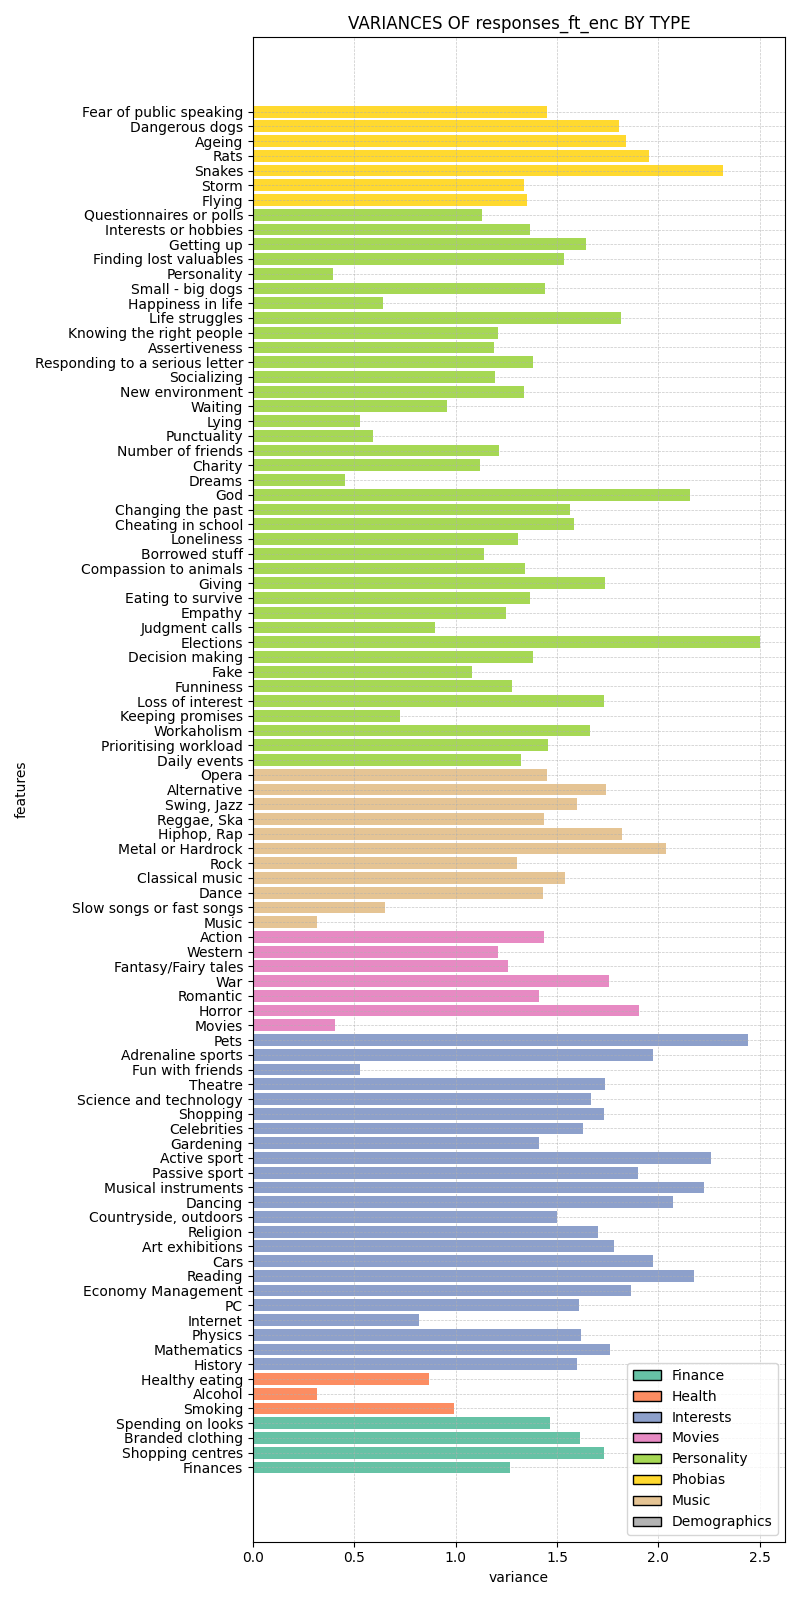


VARIANCES FOR THE FEATURES IN responses_ft_pp:


Finances                   1.00198
Shopping centres           1.00198
Branded clothing           1.00198
Spending on looks          1.00198
Smoking                    1.00198
                            ...   
Snakes                     1.00198
Rats                       1.00198
Ageing                     1.00198
Dangerous dogs             1.00198
Fear of public speaking    1.00198
Length: 93, dtype: float64

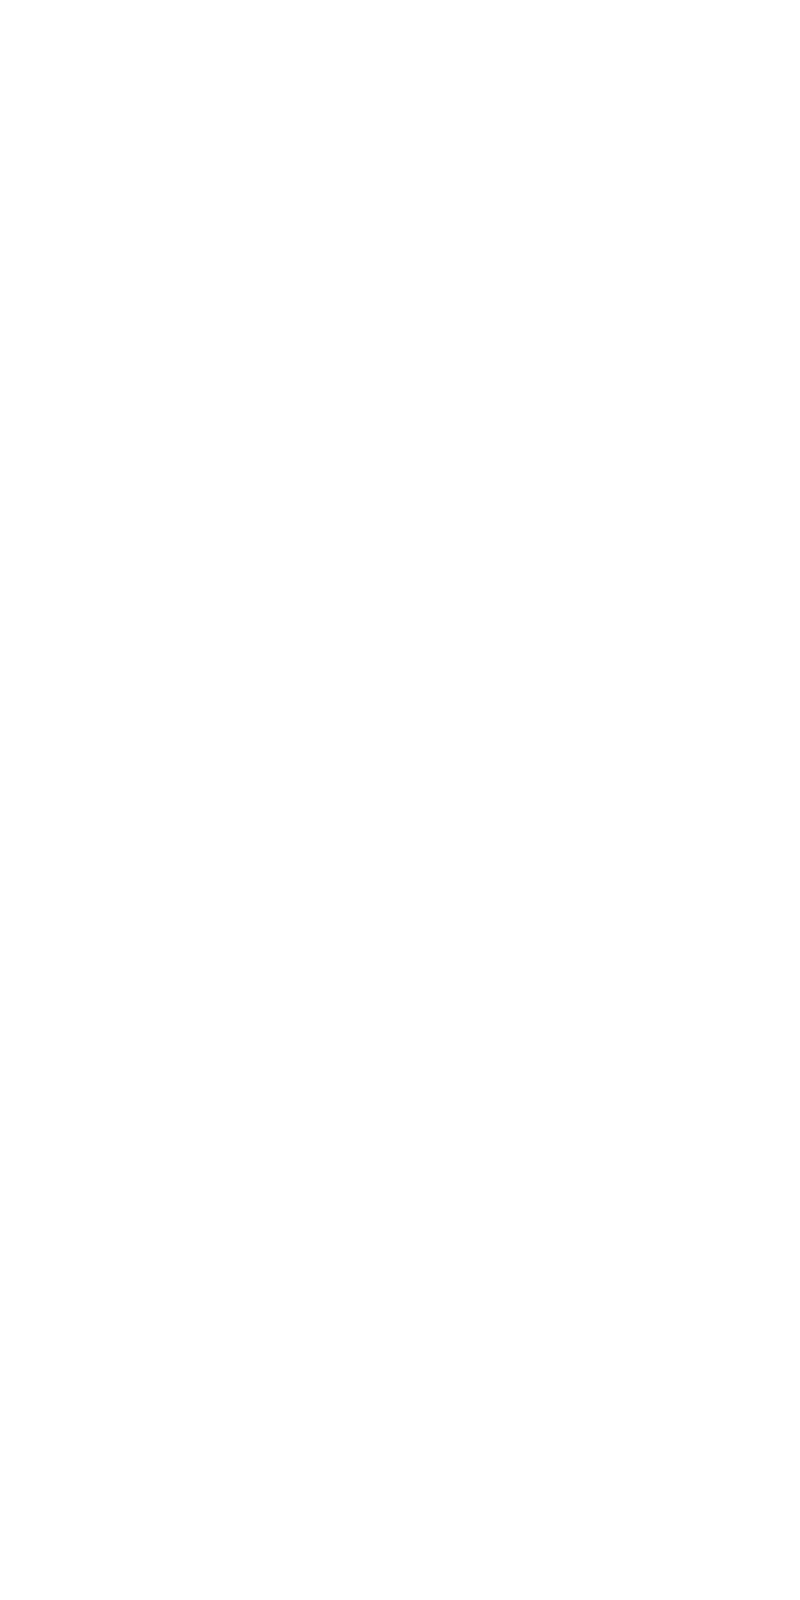

In [6]:
# adjusting colors

set_2_colors = cm.Set2.colors

colors_types = {
    "Finance": set_2_colors[0],
    "Health": set_2_colors[1],
    "Interests": set_2_colors[2],
    "Movies": set_2_colors[3],
    "Personality": set_2_colors[4],
    "Phobias": set_2_colors[5],
    "Music": set_2_colors[6],
    "Demographics": set_2_colors[7]
}

var_to_type = {}
for tp, variables in variables_by_type.items():
    for var in variables:
        var_to_type[var] = tp

columns_df = pd.read_csv('columns_hw.csv', index_col=0)
columns_df['type'] = [var_to_type[i] for i in columns_df['short'].values]
columns_df['color'] = [colors_types[i] for i in columns_df['type'].values]

feature_to_color = columns_df.set_index('short')['color'].to_dict()
features_colors = [feature_to_color[f] for f in features]

legend_feature_type_color = [Patch(facecolor=colors_types[key], edgecolor='black', label=key) for key in colors_types.keys()]

# calculating and visualising variances 

n = len(features)
vars_responses_ft_enc = responses_ft_enc.var(axis=0)
vars_responses_ft_pp = responses_ft_pp.var(axis=0)

print(f'\nVARIANCES FOR THE FEATURES IN responses_ft_enc:')
display(vars_responses_ft_enc)

plt.figure(figsize=(8, 16))
plt.barh(np.arange(n), vars_responses_ft_enc.values, color=features_colors)
plt.title("VARIANCES OF responses_ft_enc BY TYPE")
plt.yticks(ticks=np.arange(n), labels=features)
plt.ylabel('features')
plt.xlabel('variance')
plt.legend(handles=legend_feature_type_color)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

print(f'\nVARIANCES FOR THE FEATURES IN responses_ft_pp:')
display(vars_responses_ft_pp)

plt.figure(figsize=(8, 16))
plt.barh(np.arange(n), vars_responses_ft_pp.values, color=features_colors)
plt.title("VARIANCES OF responses_ft_enc BY TYPE")
plt.yticks(ticks=np.arange(n), labels=features)
plt.ylabel('features')
plt.xlabel('variance')
plt.legend(handles=legend_feature_type_color)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

#### Comment the results obtained for the variances (max 150 words):
\
The bar plot of feature variances without standardisation shows that no single feature clearly dominates and most variances lie between 0.75 and 1.75. However, a few features, such as “Pets”, “Elections”, and “Snakes”, have noticeably bigger variances than the others. In contrast, some features show much smaller variances, for example “Alcohol”, “Movies” or “Music”. It indicates that during the application of PCA features with bigger variance could dominate the results and those with smaller variance could be partially ignored. For this reason the standardisation was applied, because as it can be observed on the second bar plot, all variances are equal, which means that all features will contribute equally to the results of PCA. 

#### Write the code for computing all the $n$ PCs of the two datasets, separately, and for visualizing the curves of cumulative explained variances:

PCs PLOTS:


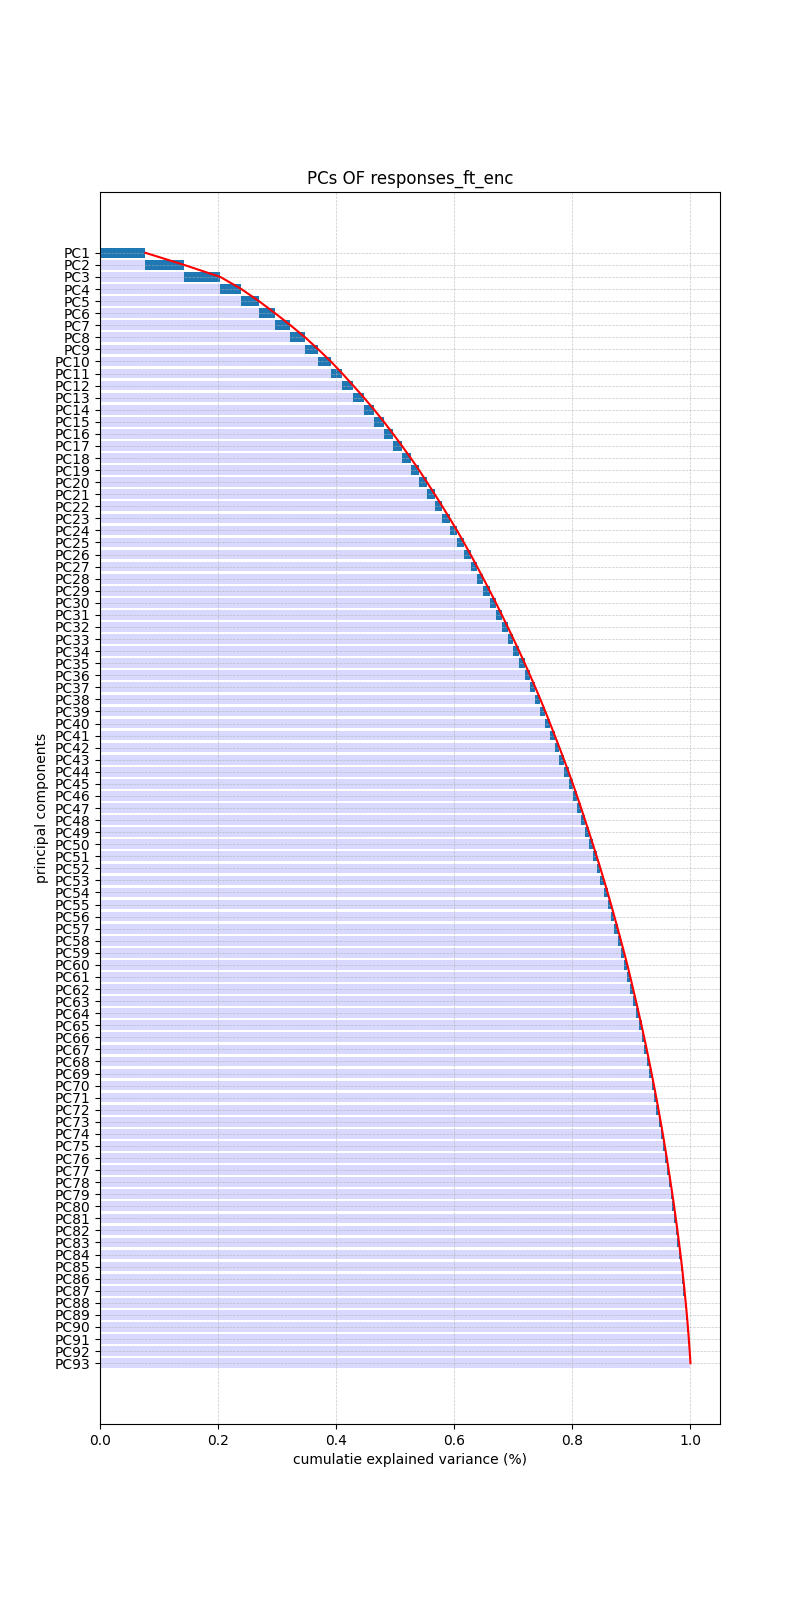

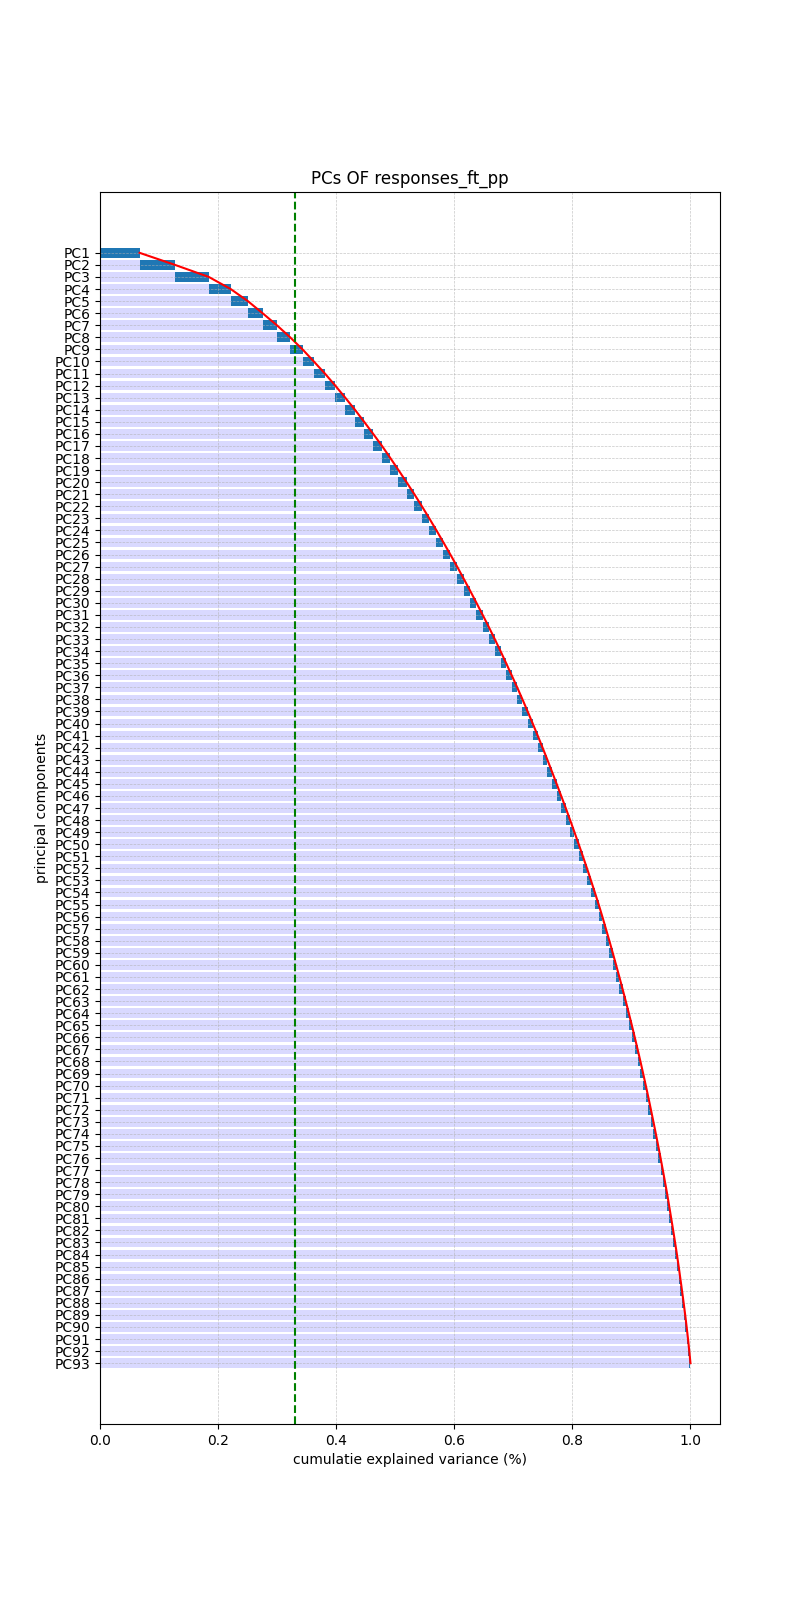

In [7]:
# applying PCA

pca_enc = PCA()
pca_pp = PCA()

pca_enc.fit(responses_ft_enc)
pca_pp.fit(responses_ft_pp)

# plotting the results

num_features_enc = pca_enc.n_features_in_
num_features_pp = pca_pp.n_features_in_

explained_variance_pca_enc = pca_enc.explained_variance_ratio_
explained_variance_pca_pp = pca_pp.explained_variance_ratio_

print(f'PCs PLOTS:')

plt.figure(figsize=(8, 16))
plt.barh(np.arange(num_features_enc), explained_variance_pca_enc, left=np.insert(np.cumsum(explained_variance_pca_enc), 0, 0)[:-1])
plt.barh(np.arange(num_features_enc), np.insert(np.cumsum(explained_variance_pca_enc), 0, 0)[:-1], color='b', alpha=0.15)
plt.plot(np.cumsum(explained_variance_pca_enc), np.arange(num_features_enc), 'r')
plt.title('PCs OF responses_ft_enc')
plt.yticks(ticks=np.arange(num_features_enc), labels=[f'PC{i}' for i in range(1, num_features_enc + 1)])
plt.ylabel('principal components')
plt.xlabel('cumulatie explained variance (%)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8, 16))
plt.barh(np.arange(num_features_pp), explained_variance_pca_pp, left=np.insert(np.cumsum(explained_variance_pca_pp), 0, 0)[:-1])
plt.barh(np.arange(num_features_pp), np.insert(np.cumsum(explained_variance_pca_pp), 0, 0)[:-1], color='b', alpha=0.15)
plt.plot(np.cumsum(explained_variance_pca_pp), np.arange(num_features_pp), 'r')
plt.axvline(x=0.33, color='green', linestyle='--', linewidth=1.5, label='33% variance')
plt.title('PCs OF responses_ft_pp')
plt.yticks(ticks=np.arange(num_features_pp), labels=[f'PC{i}' for i in range(1, num_features_pp + 1)])
plt.ylabel('principal components')
plt.xlabel('cumulatie explained variance (%)')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().invert_yaxis()
plt.show()

#### Comment the results obtained for the cumulative explained variances, knowing the vaues in the datasets and the fetures' variances (max 150 words):
\
The bar plot showing the contribution of individual principal components for the dataset without standardisation indicates that 80% of the variance is explained by the first 45 principal components, 50% by the first 17 components, and 33% by the first 8 components. For the standardised dataset, the results are very similar: 80% of the variance is explained by the first 48 components, 50% by the first 19 components, and 33% by the first 9 components. The slightly higher number of components required after standardisation suggests that scaling changed the variance distribution across features, but did not significantly affect the overall dimensionality reduction. This indicates that, even before standardisation, the original feature scales were relatively balanced and suitable for PCA.


## Exercise 3. Dimensionality Reduction and PC Interpretation

In this exercise, you have to do the following operations:
1. For the dataset *responses_ft_pp*, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
1. Visualize as a barplot the explained variance (as percentage) for each PC, and report the preserved explained variance (as percentage) by the $m$ PCs.
1. Visualize all the PCs as barplots and give an interpretation and a name to them, **motivating your choices**.
1. Transform the *responses_ft_pp* data into their $m$-dimensional representation via PCA. Store the transformed data in the variable *responses_ft_pca*;
1. Visualize the the score graph. If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs (given at the previous step) on the axes** for better understanding the results.

#### Write the code for computing the new PCA, for visualizing the $m$ PCs as barplots:

EXPLAINED VARIANCE OF 5 FEATURES: 


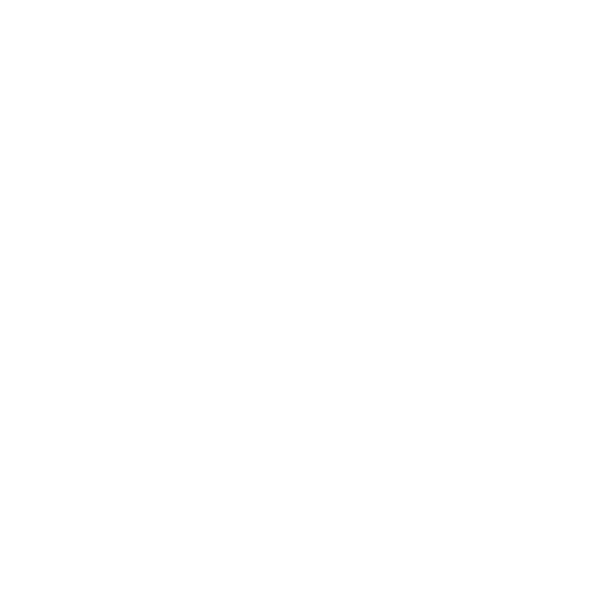


FEATURES LOADINGS WITH - AND + THRESHOLD:


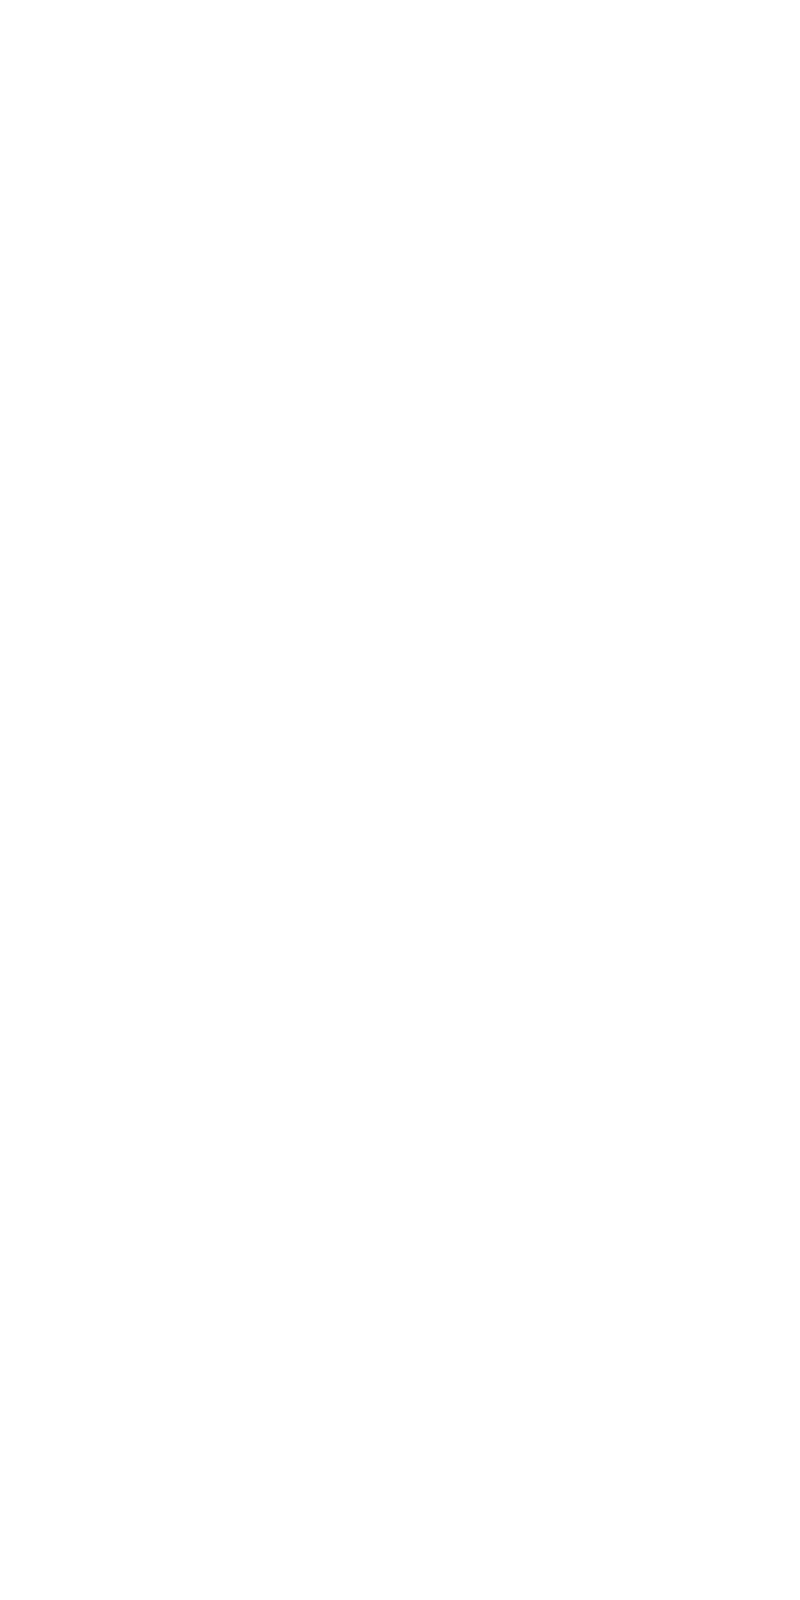

FEATURES OVER UPPER TRESHOLD:
Shopping centres
Spending on looks
Dancing
Celebrities
Shopping
Romantic
Fantasy/Fairy tales
Dance
Empathy
Giving
Compassion to animals
God
Life struggles
Storm
Snakes
Rats
Ageing
Dangerous dogs
FEATURES UNDER LOWER TRESHOLD:
History
Mathematics
Physics
PC
Science and technology
War
Western
Action
Rock
Metal or Hardrock
Small - big dogs


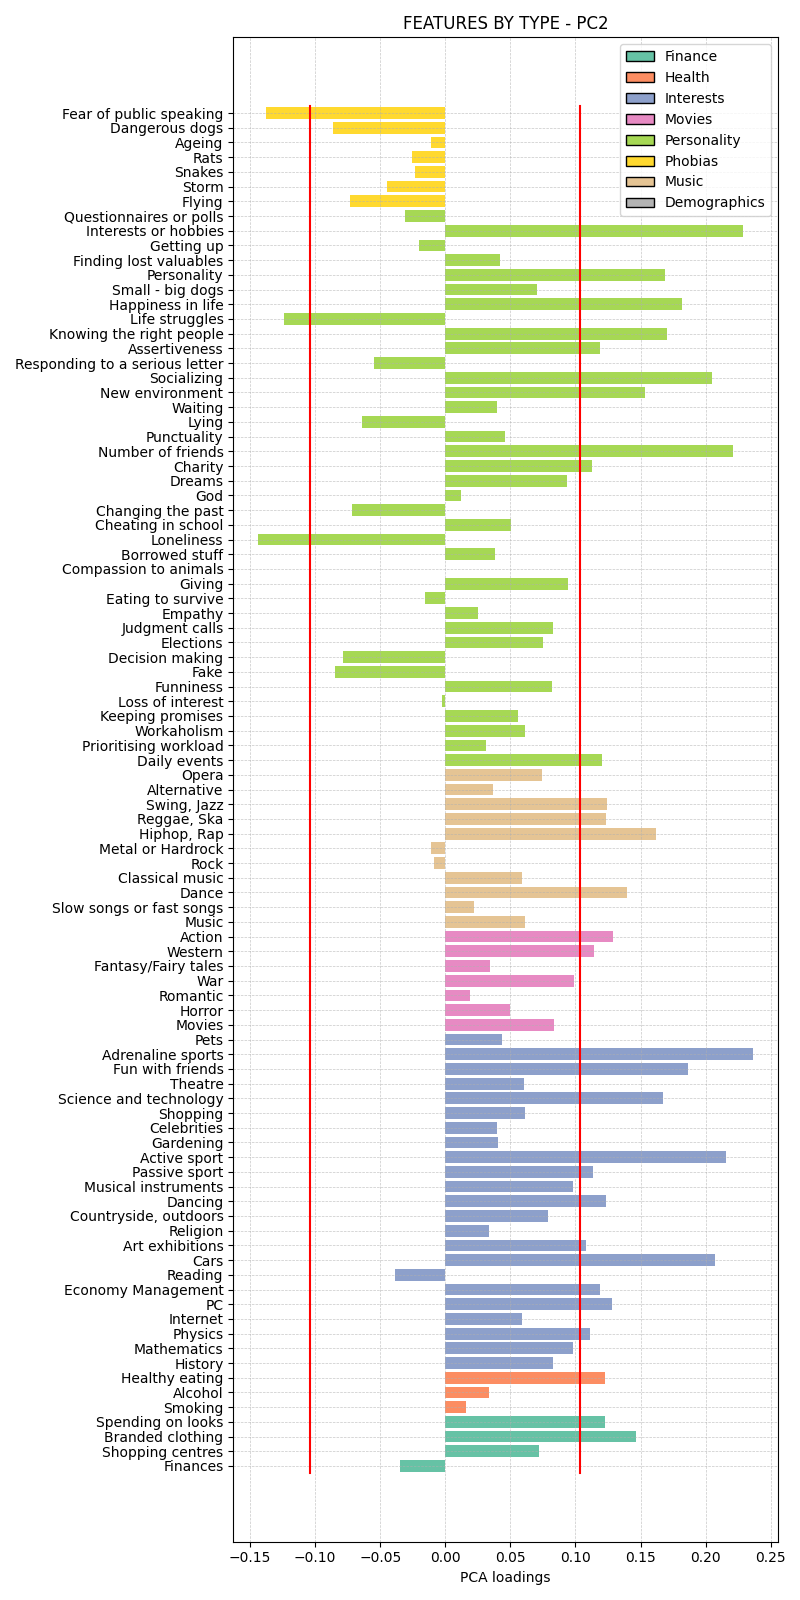

FEATURES OVER UPPER TRESHOLD:
Branded clothing
Spending on looks
Healthy eating
Physics
PC
Economy Management
Cars
Art exhibitions
Dancing
Passive sport
Active sport
Science and technology
Fun with friends
Adrenaline sports
Western
Action
Dance
Hiphop, Rap
Reggae, Ska
Swing, Jazz
Daily events
Charity
Number of friends
New environment
Socializing
Assertiveness
Knowing the right people
Happiness in life
Personality
Interests or hobbies
FEATURES UNDER LOWER TRESHOLD:
Loneliness
Life struggles
Fear of public speaking


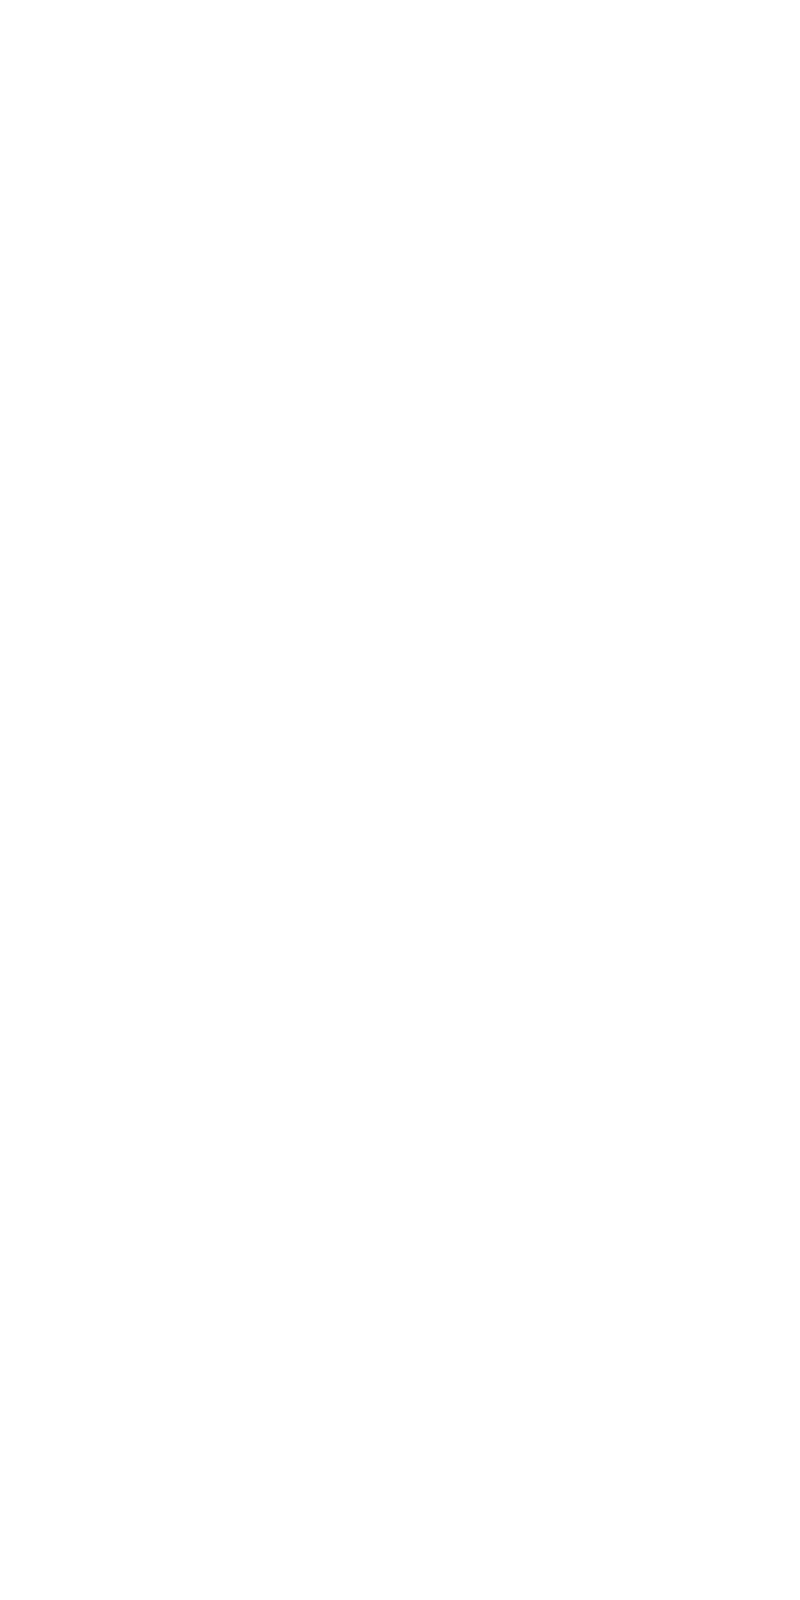

FEATURES OVER UPPER TRESHOLD:
Finances
History
Reading
Art exhibitions
Religion
Countryside, outdoors
Musical instruments
Gardening
Theatre
Classical music
Swing, Jazz
Alternative
Opera
Prioritising workload
Workaholism
Keeping promises
Elections
Charity
Finding lost valuables
Questionnaires or polls
FEATURES UNDER LOWER TRESHOLD:
Branded clothing
Cars
Hiphop, Rap
Cheating in school


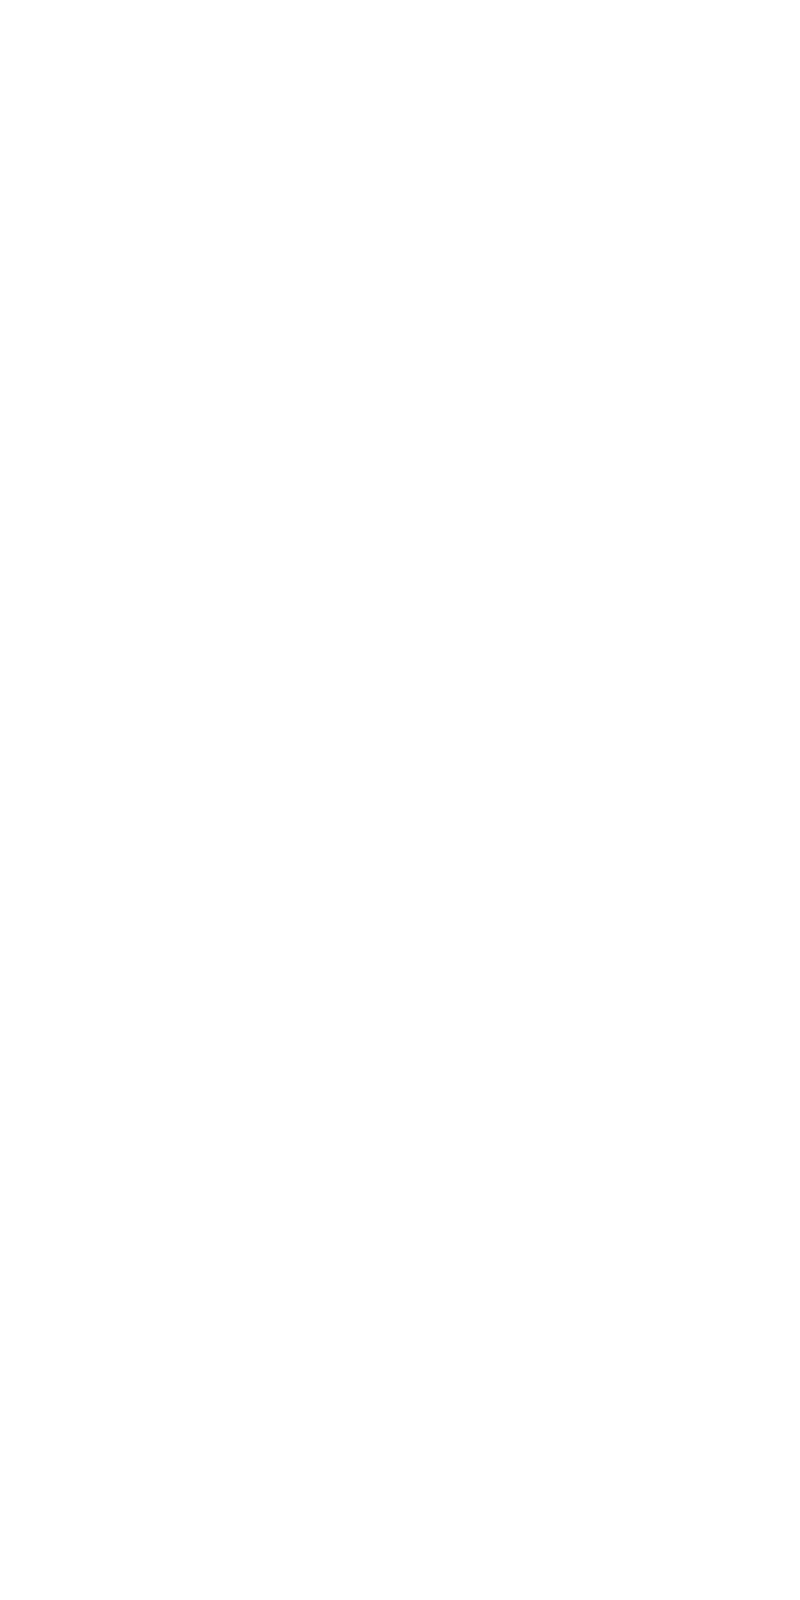

FEATURES OVER UPPER TRESHOLD:
Finances
Mathematics
Physics
PC
Economy Management
Cars
Gardening
Science and technology
Prioritising workload
Workaholism
Keeping promises
Borrowed stuff
Happiness in life
FEATURES UNDER LOWER TRESHOLD:
Smoking
Alcohol
History
Reading
Art exhibitions
Theatre
Fun with friends
Music
Rock
Swing, Jazz
Alternative
Fake
Cheating in school
Punctuality
Lying
Small - big dogs
Getting up


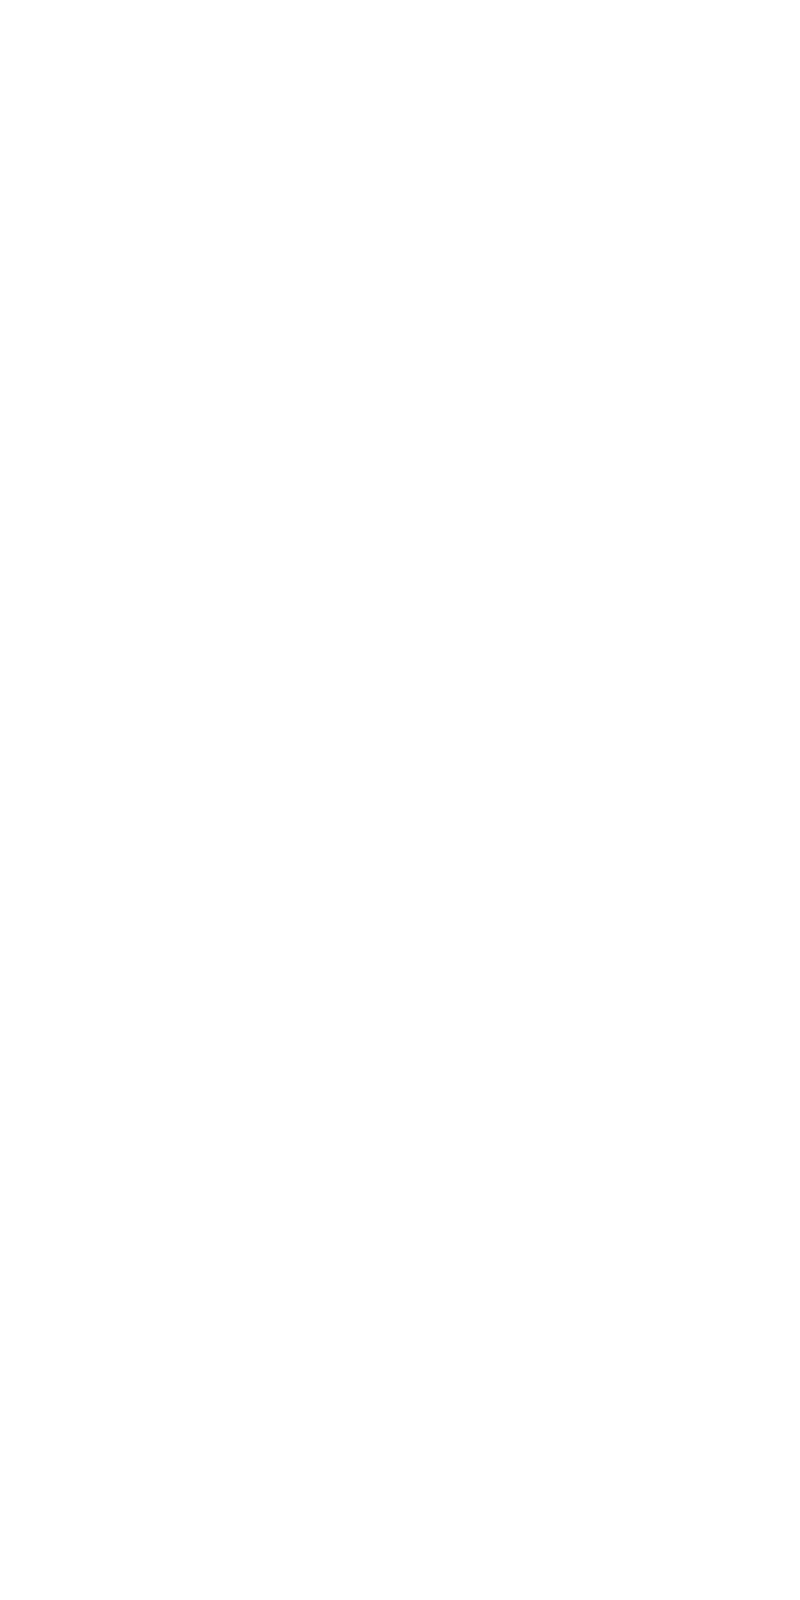

FEATURES OVER UPPER TRESHOLD:
Shopping centres
Branded clothing
Spending on looks
Internet
PC
Economy Management
Cars
Celebrities
Science and technology
War
Action
Hiphop, Rap
Daily events
Funniness
Fake
Eating to survive
Loneliness
Changing the past
Lying
Knowing the right people
Getting up
Rats
Ageing
Dangerous dogs
Fear of public speaking
FEATURES UNDER LOWER TRESHOLD:
Dreams
Number of friends
Waiting
New environment
Socializing
Happiness in life
Personality


array([[ 0.22485451,  1.17387614, -0.12815432,  3.47005251,  0.18552385],
       [-3.76227847,  0.70894944,  4.00497823,  0.42097057, -0.1270111 ],
       [-0.45694025, -1.09814317,  0.25858747, -4.34555511, -0.22921421],
       ...,
       [ 2.46052723,  0.02766356,  0.2170261 , -0.40904755, -2.32311484],
       [-3.42291196,  1.78114372,  0.69282469, -0.10921342,  1.41478867],
       [ 3.57266987,  1.3143555 , -0.77083329, -0.00925765,  0.36797393]],
      shape=(506, 5))

In [8]:
# applying final version of PCA

m = 5

pca_final = PCA(n_components=m)
pca_final.fit(responses_ft_pp)

round_explained_variance_ratio = np.round(pca_final.explained_variance_ratio_.sum() * 100, decimals=2)
tresh = np.sqrt(1 / pca_final.n_features_in_)
explained_variance_pca_final = pca_final.explained_variance_ratio_
num_features_final = pca_final.n_features_in_

# plotting explained variance of m features

print(f'EXPLAINED VARIANCE OF {m} FEATURES: ')

plt.figure(figsize=(6, 6))
plt.bar(range(1, m+1), explained_variance_pca_final*100)
plt.title(f'PCs\' EXPLAINED VARIANCE ({round_explained_variance_ratio}% OF TOTAL EXPLAINED VARIANCE)')
plt.xticks(ticks=np.arange(1, m+1), labels=[f'PC{i}' for i in range(1, m+1)], rotation=45)
plt.xlabel('principal components')
plt.ylabel('% of explained variance')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# plotting features loadings (parts) with threshold

print(f'\nFEATURES LOADINGS WITH - AND + THRESHOLD:')

for i in range(m):
    plt.figure(figsize=(8, 16))
    plt.barh(np.arange(num_features_final), pca_final.components_[i, :], color=features_colors)
    plt.plot([tresh, tresh], [-0.5, num_features_final - 0.5], 'red')
    plt.plot([-tresh, -tresh], [-0.5, num_features_final - 0.5], 'red')
    plt.yticks(ticks=np.arange(num_features_final), labels=features)
    plt.title(f'FEATURES BY TYPE - PC{i+1}')
    plt.xlabel('PCA loadings')
    plt.legend(handles=legend_feature_type_color)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()

    loadings = pca_final.components_[i, :]
    ids_over_upper_tresh = np.argwhere(loadings >= tresh).flatten()
    ids_under_lower_tresh = np.argwhere(loadings <= -tresh).flatten()

    features_array = np.array(features)
    features_over_upper_tresh = features_array[ids_over_upper_tresh]
    features_under_lower_tresh = features_array[ids_under_lower_tresh]

    print(f'FEATURES OVER UPPER TRESHOLD:')
    
    for j in range(len(features_over_upper_tresh)):
        print(features_over_upper_tresh[j])

    print(f'FEATURES UNDER LOWER TRESHOLD:')
    
    for j in range(len(features_under_lower_tresh)):
        print(features_under_lower_tresh[j])


responses_ft_pca = pca_final.transform(responses_ft_pp)
responses_ft_pca

#### For each PC, write the name you assigned to it and a brief interpretation that motivate the choice (max 100 words per PC):
\
PC1: (-) stereotypical male character vs stereotypical female character(+)\
Firstly, the positive side is influenced by several values related to phobias such as fear of rats, storms, aging or dogs. It is believed that usually girls are scared of such things. Moreover, features like dancing, shopping and spending on looks, romantic movies or interest in celebrities have a strong positive contribution, which are usually associated with stereotypical women's interests. On the negative side, science features can be observed, including technology, PC, physics and mathematics. Additionally, a strong influence comes from westerns and war movies or metal music, which are stereotypically associated with man.
\
\
PC2: (-) introvert character vs extravert character (+)\
The most noticeable thing is that the negative side is mainly influenced by three features: fear of public speaking, life struggles, and loneliness. These traits are often linked to more introverted people. In contrast, the positive side is dominated by features such as number of friends, socializing, strong personality and enjoying new environments, which are typically associated with extraverts. Moreover, more sociable people tend to be energetic and spontaneous, which explains the strong influence of active and adrenaline sports or going out with friends, on the positive side.
\
\
PC3: (-) working class culture vs elites culture (+)\
Firstly, the positive side is dominated by features usually linked to elites and high-culture interests, such as opera, classical music, theater or art exhibitions. Strong contributions also come from activities like reading or playing a musical instrument, workaholism and giving money to charities. In contrast, the negative side is influenced by features such as cheating in school, interest in hiphop or rap, cars and branded clothing. Although branded clothing could be also linked to wealth, in this context it could be more strongly linked to street and hip-hop culture. Therefore, this side can be described as more working-class oriented.
\
\
PC4: (-) hedonistic lifestyle vs career-focused lifestyle (+)\
The most noticeable thing is that the negative side is dominated by alcohol and smoking. Strong contributions also come from problems with getting up and punctuality, lying and cheating at schools. This side could be linked to a dysfunctional family, however since there is also a strong influence from interest in music, especially rock and alternative, or theatre, it can be associated with just careless, hedonistic lifestyle. In contrast, the positive side is dominated by features such as prioritising workload, workaholism, keeping promises, interest in science, especially maths and physics. Caring about finances also contributes, which suggests a profile associated with better career prospects.
\
\
PC5: (-) positive and open people vs anxious individualists (+)\
The most noticeable thing is that the negative side is dominated by personality-related features such as belief in one’s personality, happiness in life, socializing and enjoying new environments or number of friends. These traits are directly linked to positive and open people. In contrast, the positive side is influenced by many features related to phobias and the desire to change the past, which would indicate a more anxious personality. Moreover, there is a big contribution of the loneliness aspect and interest in science, PCs or the internet, therefore this side can be associated with more individualistic people.


#### Write the code for visualizing the score graph (with PC names on the axis):

RESPONSES DATASET:



,(-) stereotypical male character vs stereotypical female character (+),(-) introvert character vs extravert character (+),(-) working class culture vs elites culture (+),(-) hedonistic lifestyle vs career-focused lifestyle (+),(-) positive and open people vs anxious individualists (+)
0,0.224855,1.173876,-0.128154,3.470053,0.185524
1,-3.762278,0.708949,4.004978,0.420971,-0.127011
2,-0.456940,-1.098143,0.258587,-4.345555,-0.229214
3,-1.306048,-1.712087,1.813567,-0.791069,-3.880320
4,-2.711131,0.950112,1.300676,-3.146045,-0.427120
...,...,...,...,...,...
501,1.745744,3.025914,4.016146,0.227438,-1.396525
502,-0.653121,-0.264549,-3.101100,4.794464,1.637649
503,2.460527,0.027664,0.217026,-0.409048,-2.323115
504,-3.422912,1.781144,0.692825,-0.109213,1.414789


PCA RESULTS ON PLOTS:



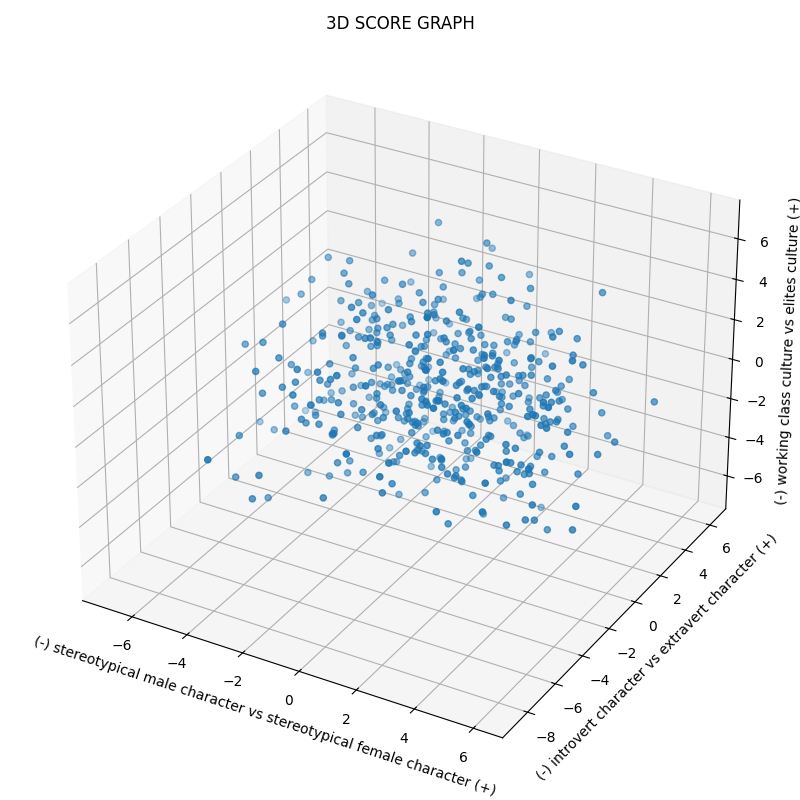

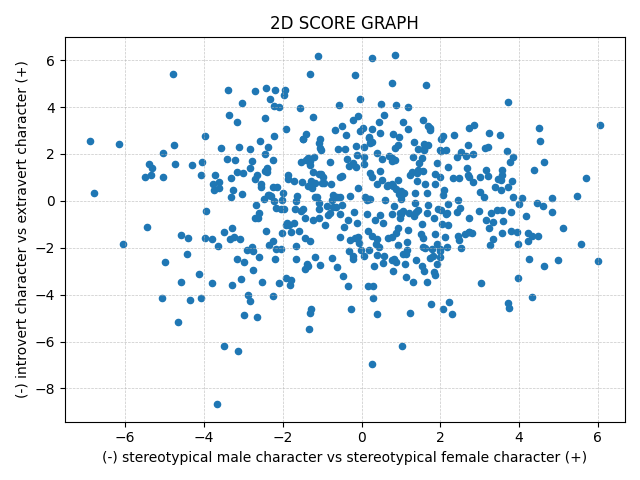

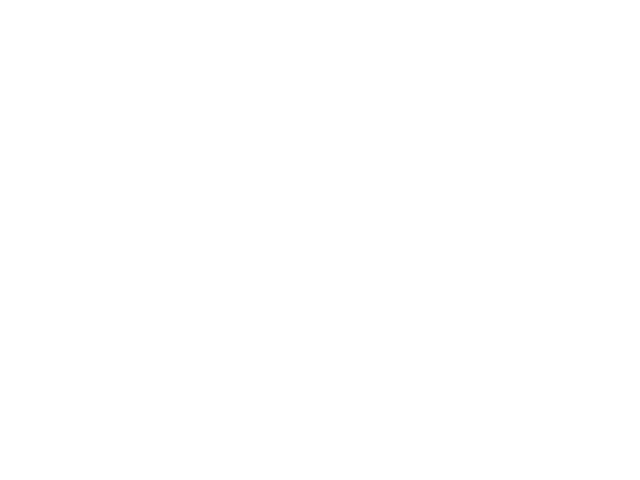

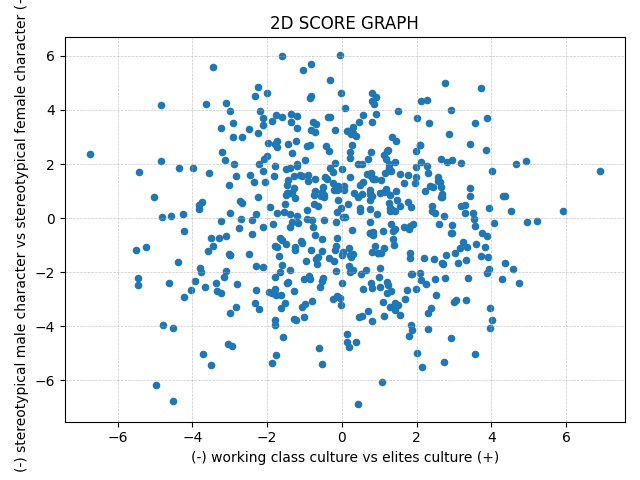

In [9]:
# get pca results

pc_names = [
    '(-) stereotypical male character vs stereotypical female character (+)',
    '(-) introvert character vs extravert character (+)',
    '(-) working class culture vs elites culture (+)',
    '(-) hedonistic lifestyle vs career-focused lifestyle (+)',
    '(-) positive and open people vs anxious individualists (+)'
]

Y = pca_final.transform(responses_ft_pp)
responses_ft_pca = pd.DataFrame(
    Y,
    columns=pc_names
)

print(f'RESPONSES DATASET:\n')
display(responses_ft_pca)

# plot pca results 

print(f'PCA RESULTS ON PLOTS:\n')

pc_plot_3d = plt.figure(figsize=(8,8))
ax_pc_plot_3d = pc_plot_3d.add_subplot(111, projection='3d')
ax_pc_plot_3d.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=20)
plt.title('3D SCORE GRAPH')
ax_pc_plot_3d.set_xlabel(pc_names[0])
ax_pc_plot_3d.set_ylabel(pc_names[1])
ax_pc_plot_3d.set_zlabel(pc_names[2])
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(Y[:, 0], Y[:, 1], s=20)
plt.title(f'2D SCORE GRAPH')
plt.xlabel(pc_names[0])
plt.ylabel(pc_names[1])
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(Y[:, 1], Y[:, 2], s=20)
plt.title(f'2D SCORE GRAPH')
plt.xlabel(pc_names[1])
plt.ylabel(pc_names[2])
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(Y[:, 2], Y[:, 0], s=20)
plt.title(f'2D SCORE GRAPH')
plt.xlabel(pc_names[2])
plt.ylabel(pc_names[0])
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

## Exercise 4. $k$-Means

In this exercise, you have to do the following operations:
1. Run the $k$-Means for clustering the data of *responses_ft_pca*, **setting the input argument *random_state* equal to the variable *random_seed*** (i.e., the minimum of the Student IDs).

   In particular, **use the silohuette score for identifying the best value for $k\in\{3, \ldots, 10\}$** and show it by plotting how the score changes w.r.t. $k$.
1. Plot the score graph again, but add the centroids of the cluster and color the points according to their cluster.
1. Visualize the centroids coordinates as barplots and **give a name and an interpretation to them by exploiting the PC names**.


#### Write the code for performing the items of the list above:

new highest silhouette score (0.1657203801138551) found for k: 3
new highest silhouette score (0.16646943517604976) found for k: 4
the best result obtained for k = 4

SILHOUETTE SCORE FOR DIFFERENT VALUES OF k:



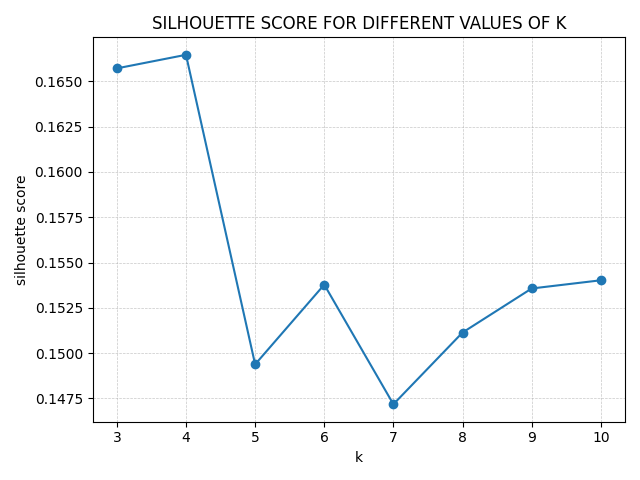

KMEANS RESULTS ON PLOTS:



/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/200367749.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


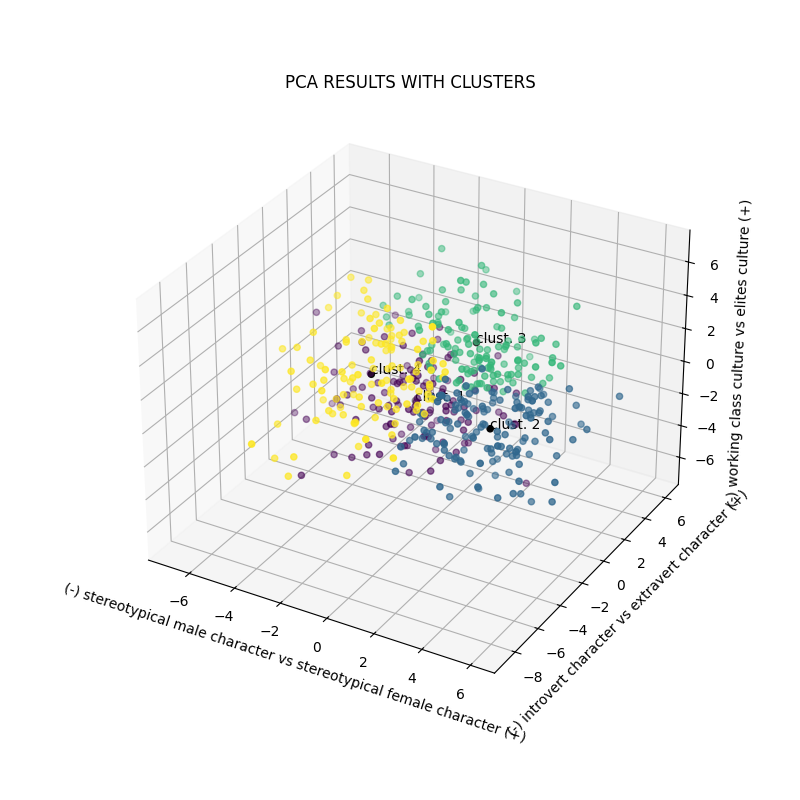

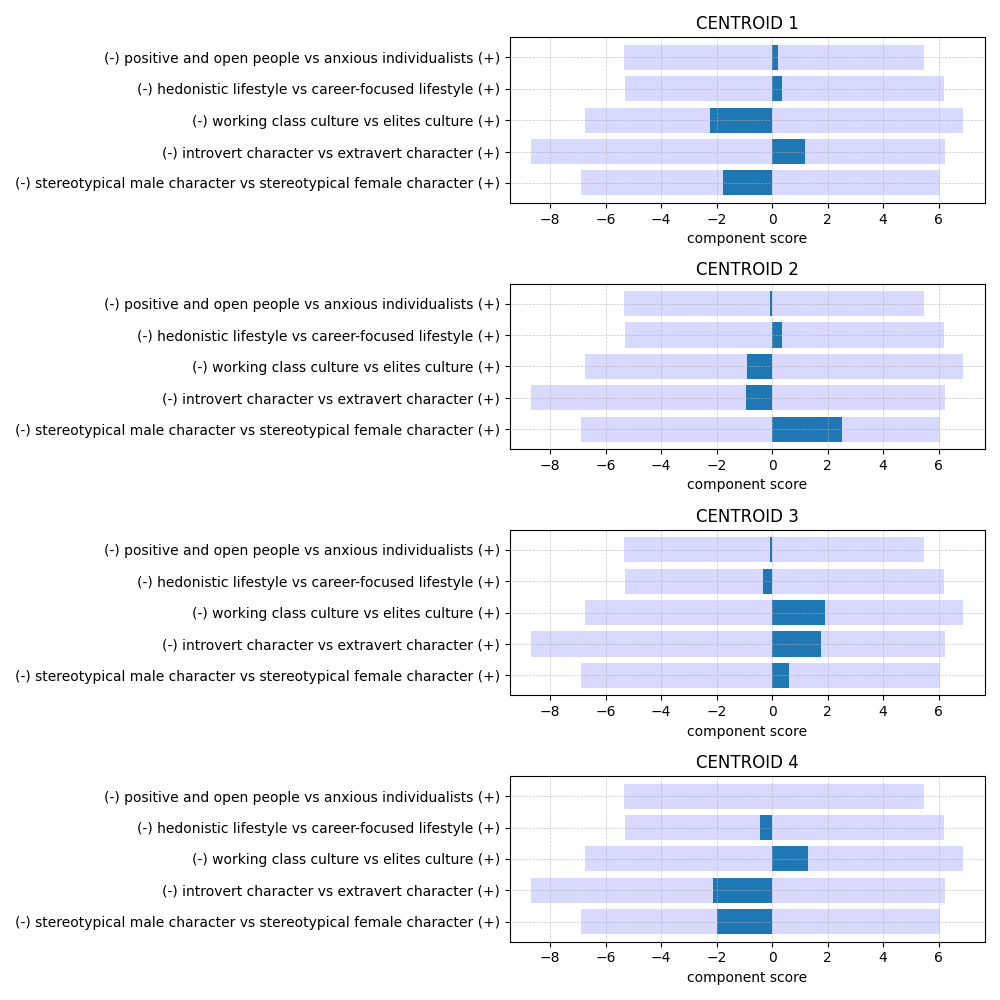

In [10]:
# computing best k for kmeans

silhouette_coef = 0
k_optimal = 0

silhouette_scores = []

for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=random_seed)
    km.fit(Y)
    res = silhouette_score(Y, km.labels_)

    silhouette_scores.append(res)

    if res > silhouette_coef:
        silhouette_coef = res
        k_optimal = k
        print(f'new highest silhouette score ({silhouette_coef}) found for k: {k}')

print(f'the best result obtained for k = {k_optimal}\n')

# plotting silhouette score

print(f'SILHOUETTE SCORE FOR DIFFERENT VALUES OF k:\n')

plt.figure()
plt.plot(range(3, 11), silhouette_scores, 'o-')
plt.title('SILHOUETTE SCORE FOR DIFFERENT VALUES OF K')
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# final KMeans

km = KMeans(n_clusters=k_optimal, random_state=random_seed)
km.fit(Y)

# plotting the results with clusters

print(f'KMEANS RESULTS ON PLOTS:\n')

pc_plot_3d_km = plt.figure(figsize=(8,8))
ax_pc_plot_3d_km = pc_plot_3d_km.add_subplot(111, projection='3d')
ax_pc_plot_3d_km.scatter(Y[:, 0], Y[:, 1], Y[:, 2], c=km.labels_, s=20)
ax_pc_plot_3d_km.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], c='black')
for k in range(k_optimal):
    ax_pc_plot_3d_km.text(km.cluster_centers_[k, 0], km.cluster_centers_[k, 1], km.cluster_centers_[k, 2], f'clust. {k+1}')
plt.title('PCA RESULTS WITH CLUSTERS')
ax_pc_plot_3d_km.set_xlabel(pc_names[0])
ax_pc_plot_3d_km.set_ylabel(pc_names[1])
ax_pc_plot_3d_km.set_zlabel(pc_names[2])
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# plotting the clusters contributions

max_values_y = Y.max(axis=0)
min_values_y = Y.min(axis=0)
dims = km.cluster_centers_.shape[1]

fig_centroids, ax_centroids = plt.subplots(k_optimal, 1, figsize=(10,10))
fig_centroids

for i in range(k_optimal):
    ax = ax_centroids[i]
    ax.barh(np.arange(dims), max_values_y, color='blue', alpha=0.15)
    ax.barh(np.arange(dims), min_values_y, color='blue', alpha=0.15)
    ax.barh(np.arange(dims), km.cluster_centers_[i, :])
    ax.set_yticks(ticks=np.arange(dims))
    ax.set_yticklabels(labels=pc_names)
    ax.set_xlabel('component score')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_title(f'CENTROID {i+1}')
    plt.tight_layout()

plt.show()

#### For each Centroid, write the name you assigned to it and a brief interpretation that motivate the choice by exploiting the PC names(max 100 words per centroid):

centroid 1: extravert working-class man\
The biggest influence in this cluster comes from a strong negative value along PC3 (around −2), corresponding to a working-class cultural orientation. A slightly larger than -2, similar negative value is observed for PC1, indicating a tendency towards a stereotypically male profile. In contrast, the centroid shows a positive value along PC2 (approximately +1.3), suggesting an extraverted character. The remaining components, PC4 and PC5, are significantly smaller than the other PCs and close to zero, therefore do not really contribute to the interpretation of this cluster.
\
\
centroid 2: introvert working-class women\
This cluster is dominated by a strong positive value along PC1 (around 2.5), clearly corresponding to a stereotypical female character. Notable values are observed for PC2 and PC3 (around -0.9), but not small enough to be ignored, indicating a tendency towards an introverted character and a working class culture. Similar to the first cluster, the remaining components, PC4 and PC5, are close to zero, therefore do not really contribute to the interpretation of this cluster.
\
\
centroid 3: elites extraverts\
This cluster is not clearly dominated by a single component, instead is shaped by significant positive values along PC2 and PC3 (around 1.85), indicating a tendency towards extravert character with an elite cultural orientation. The remaining components, PC1, PC4 and PC5 are notably smaller than the other PCs and do not really contribute to the interpretation, however the value of PC1 is around 0.5, which could indicate a slightly more female character in this group. 
\
\
centroid 4: elites introverted and slightly hedonistic man\
The biggest influence in this cluster comes from a strong negative value along PC2 (around -2), corresponding to an introvert character. A slightly larger than -2, similar negative value is observed for PC1, indicating a tendency towards a stereotypically male profile. In contrast, the centroid shows a positive value along PC3 (approximately 1.3), suggesting an elite culture. Moreover, a marginal positive value can be observed along PC4, suggesting a slightly hedonistic character. Similar to the previous groups, the value of PC5 is extremely close to 0, hence can be ignored. 


## Exercise 5. Cluster External Evaluations

In this exercise, you have to do the following operations:
1. Select a subset meaningful labels for performing an external evaluation of the clustering results.
1. For each selected label, visualize the distribution of the label in each cluster and in the whole dataset.
1. Visualize the score graph with dots colored with respect to the label value; then, visualize the clusters in separated score-graphs, coloring the points according to the label values.


#### List the Labels you consider meaningful for an external cluster evaluation and motivate your choice (max 50 words per label):

Gender: crucial variable for evaluating the most significant component, which is PC1: (-) stereotypical man vs stereotypical women (+), because it will directly evaluate if the observed component correlates with biological sex in the dataset. This is particularly important since several clusters were assigned a gender.

Education: this label can be highly effective in evaluating the correctness of PC3: (-) working class vs elites (+), because usually the elite families focus on a solid, higher education, while the working class more often choose technical or vocational school to start working at an earlier age.

Home Town Type: this is a versatile label that helps evaluate two PCs. First, PC3: (-) working class vs elites (+), because usually elites live in the cities / suburbs, while working class can live in the villages. Second, it can help with evaluation of PC2: (-) introverts vs extraverts (+) as people living in cities typically have more opportunities for social interaction than people in villages, therefore they can seem to be more extraverted. 

Home Type: this label can also be helpful in evaluating correctness of PC3: (-) working class vs elites (+). Elite families usually opt for a big, detached house or villa, which are associated with wealth, while the working class more often live in a flat.

#### Write the code for the visualizations cited in item 2 above:

EXTERNAL EVALUATION ON PLOTS:



/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


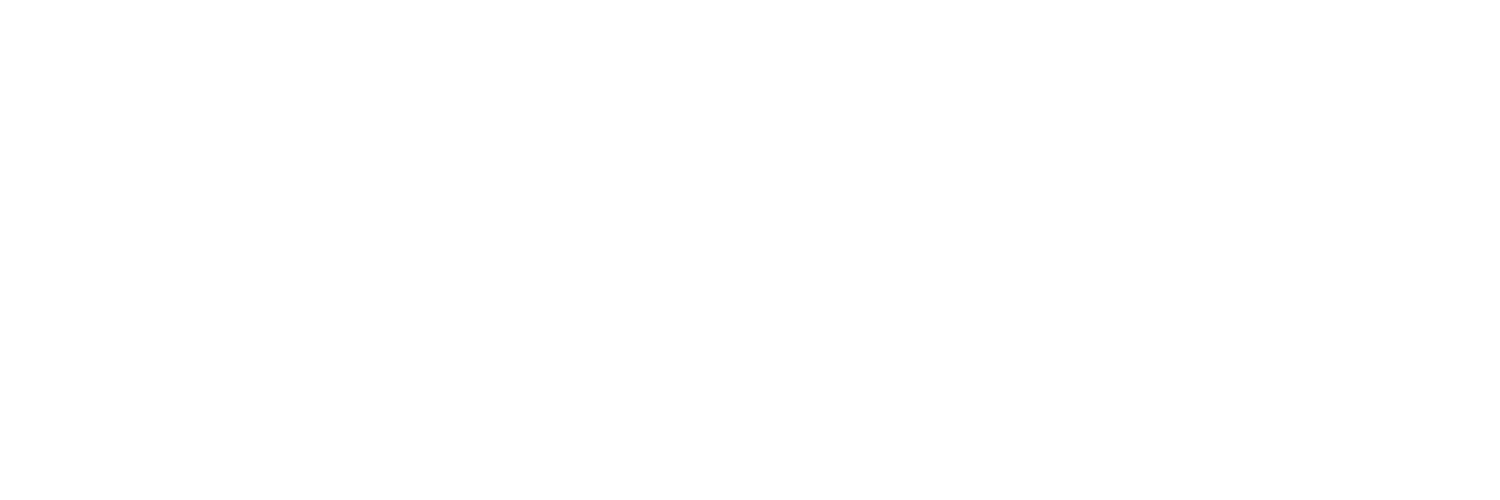

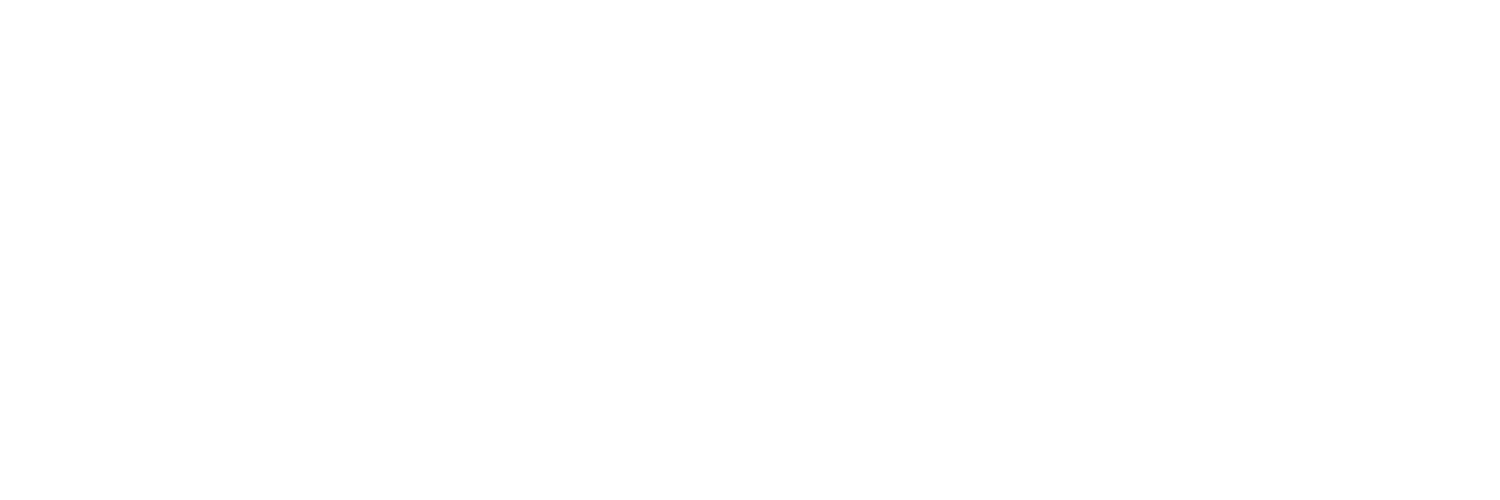

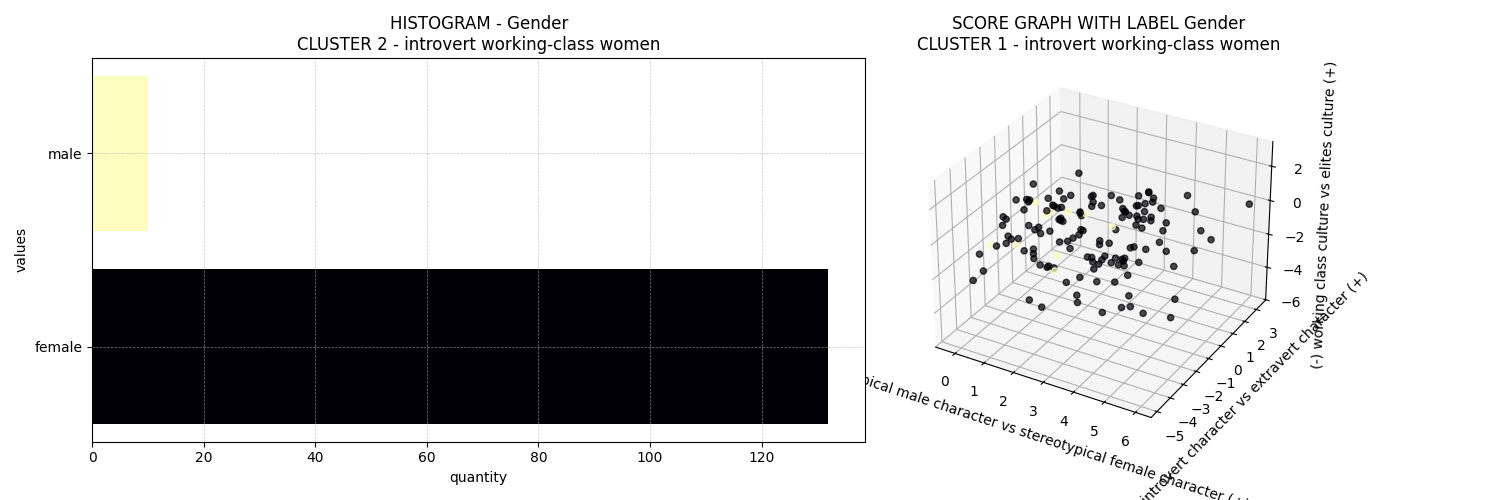

/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:68: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_clusters = plt.figure(figsize=(15, 5))


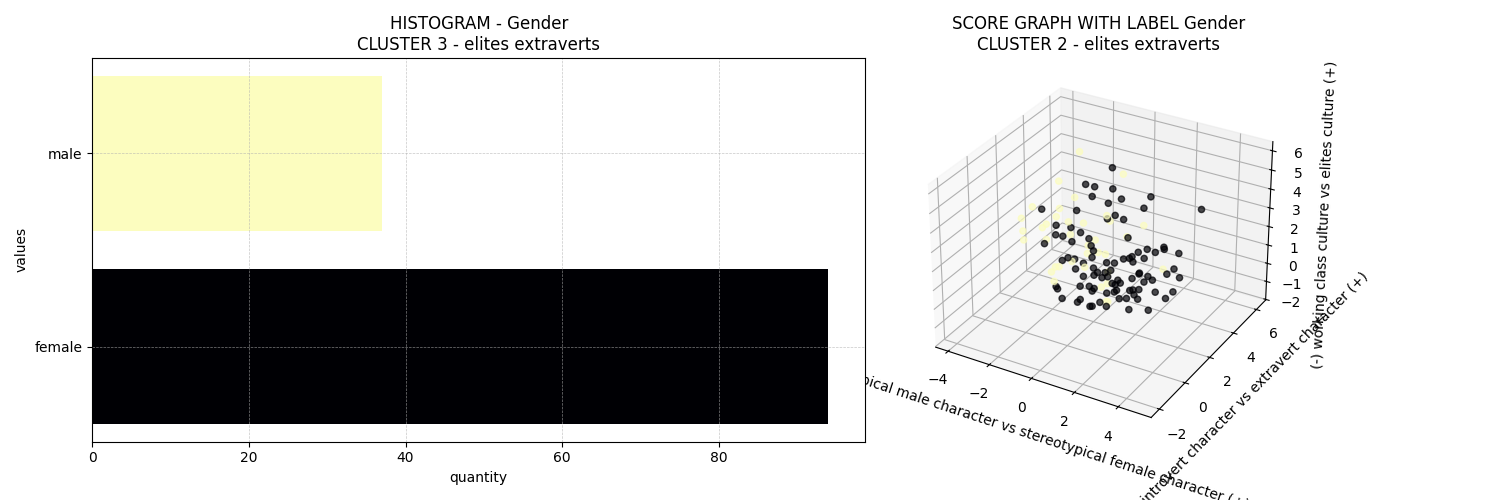

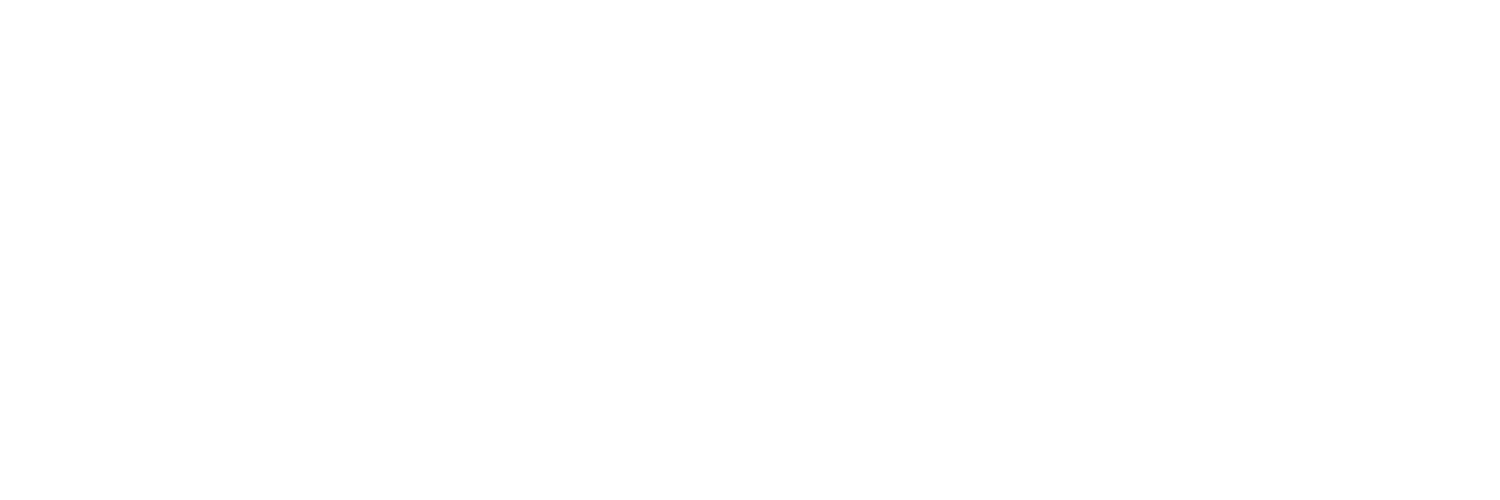

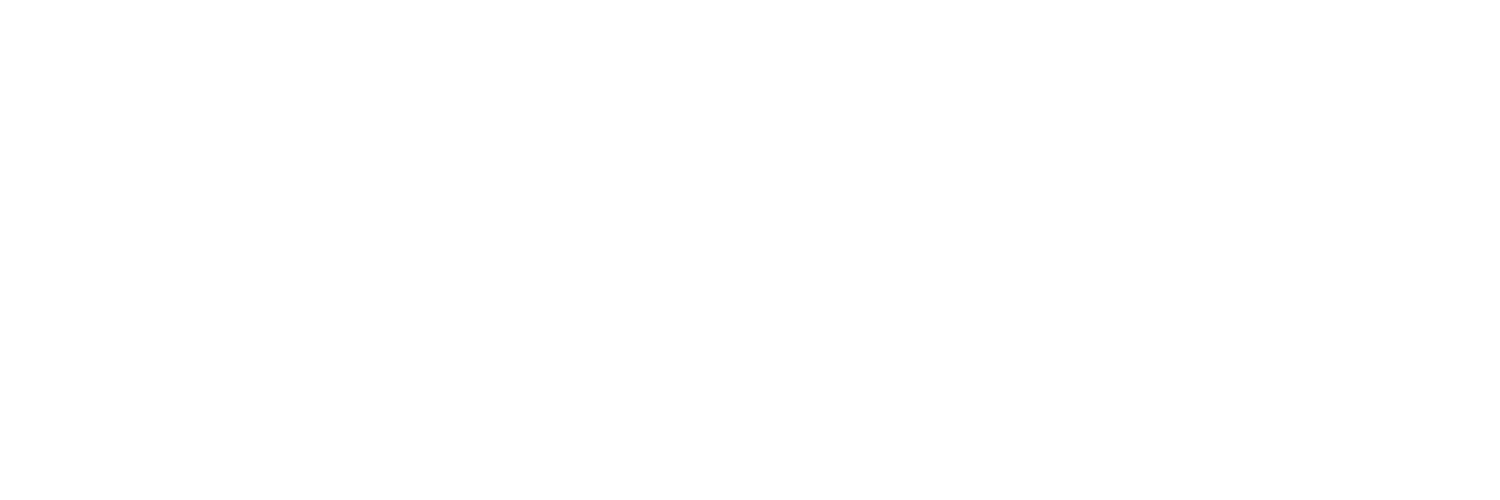

/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:86: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


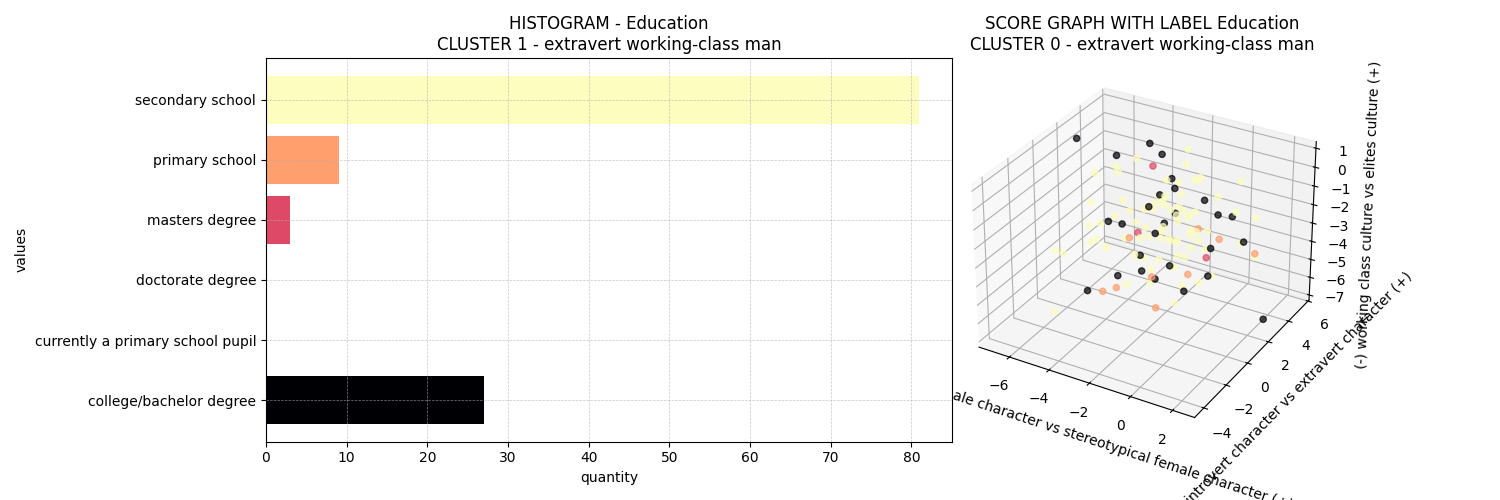

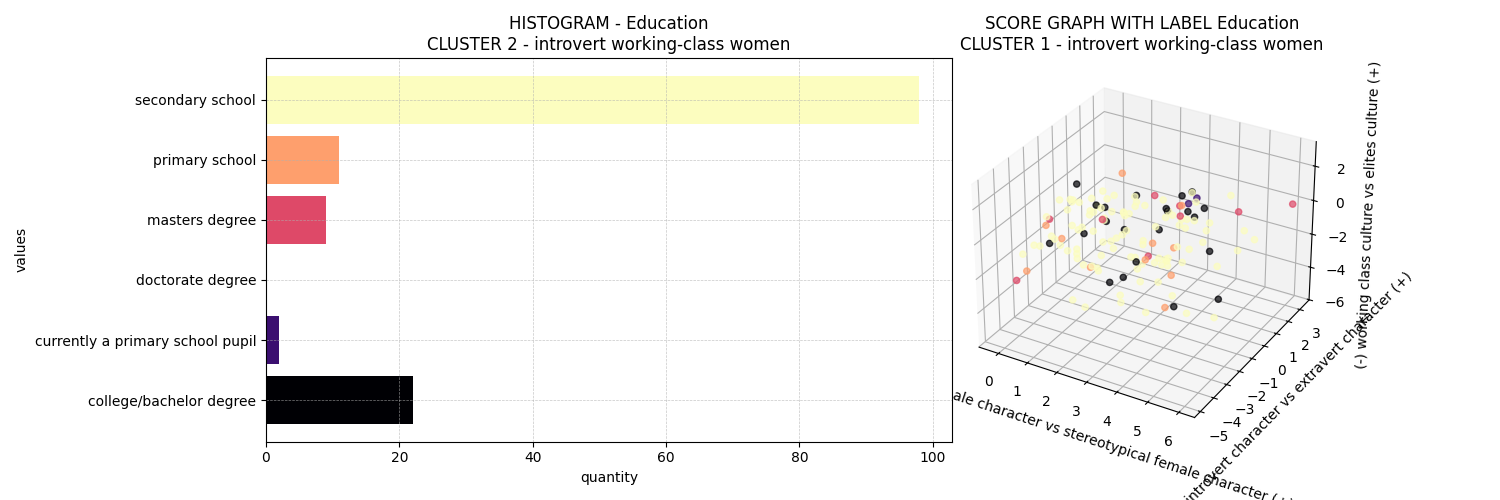

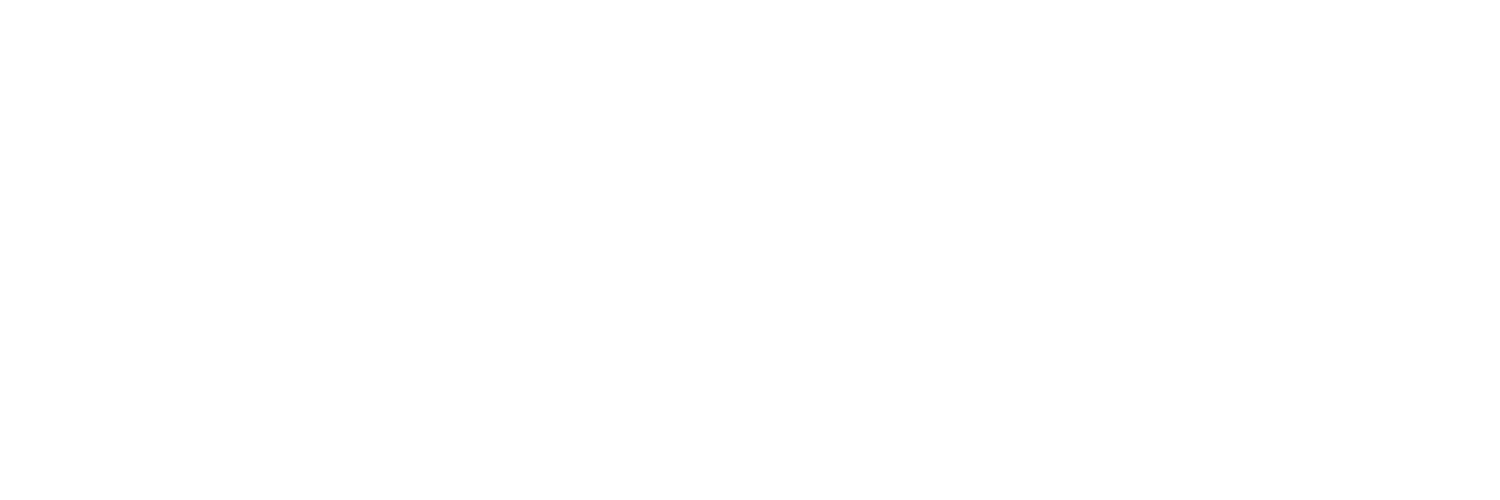

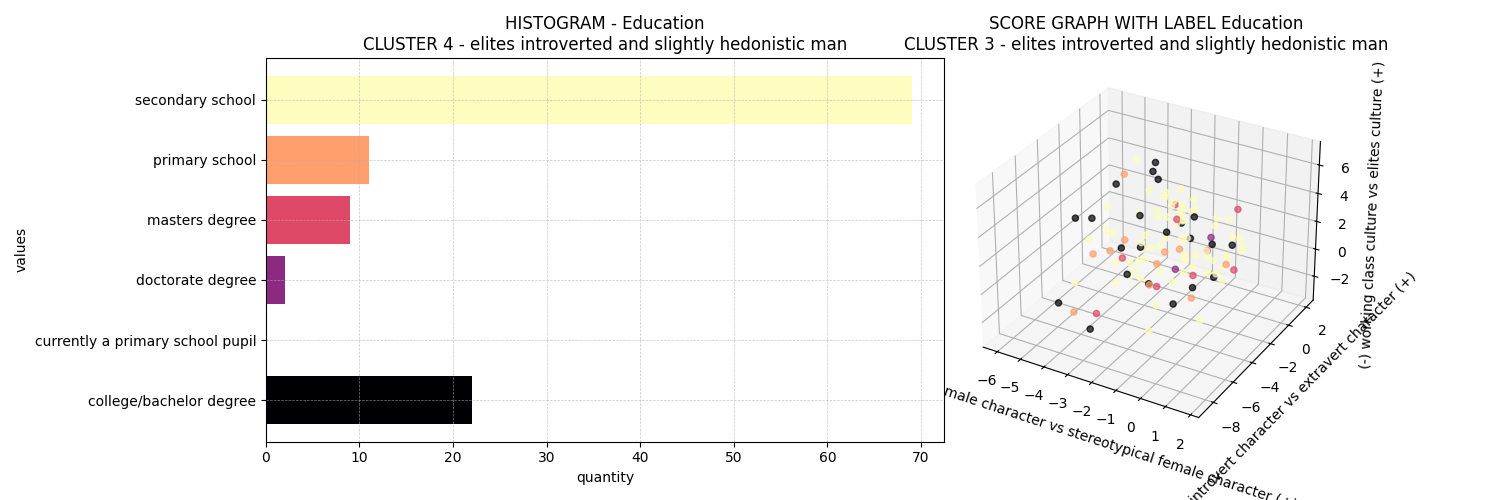

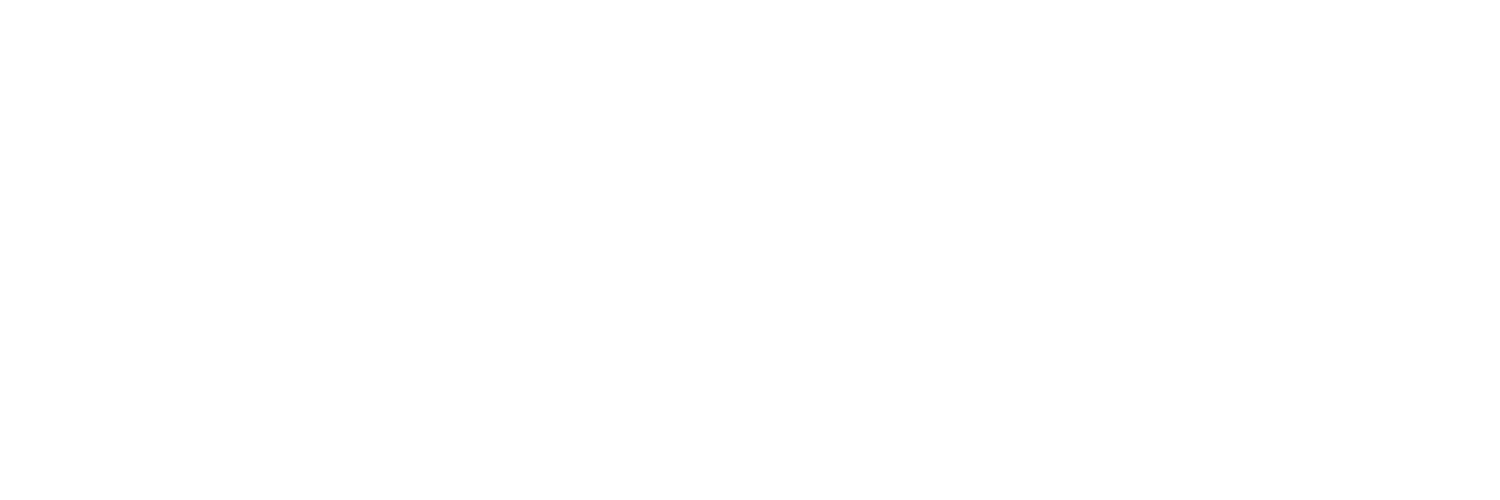

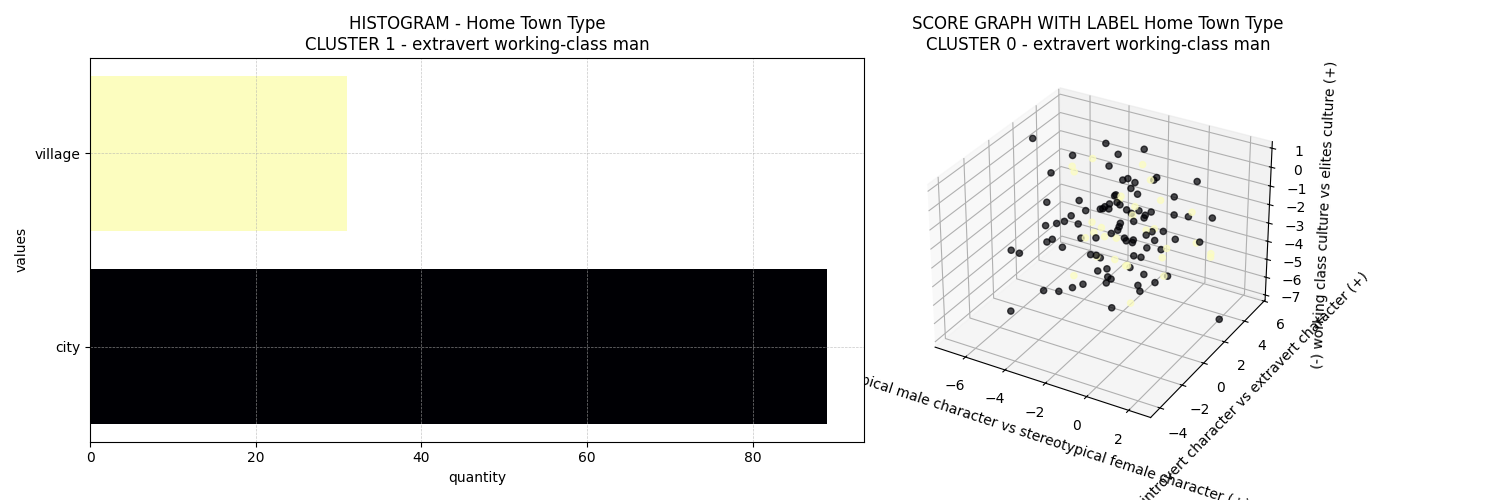

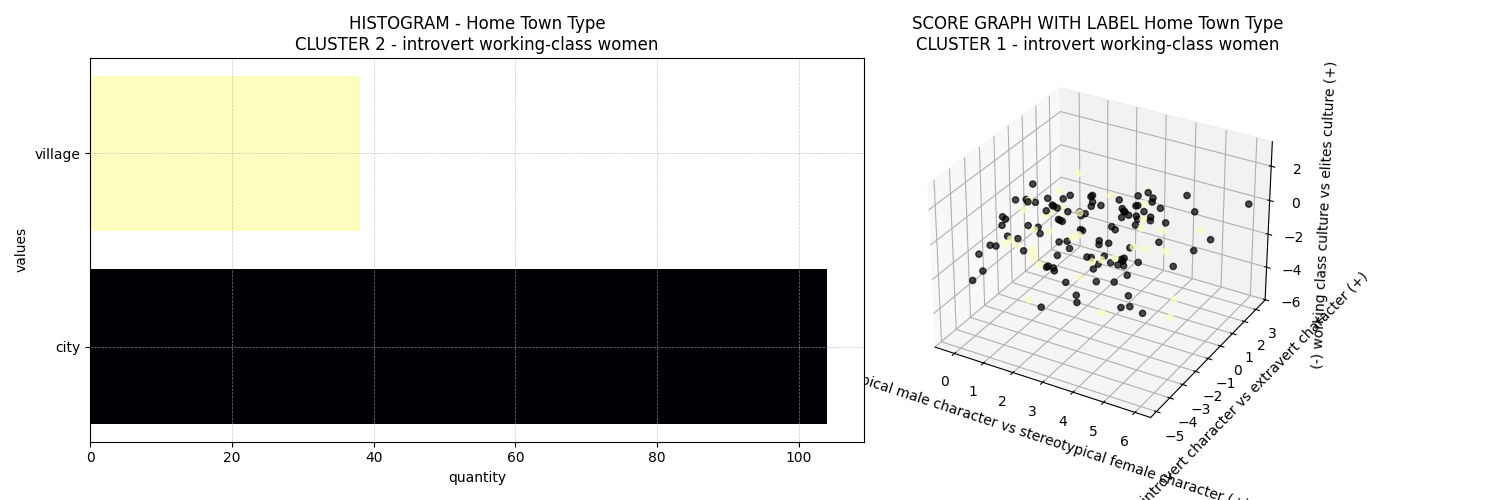

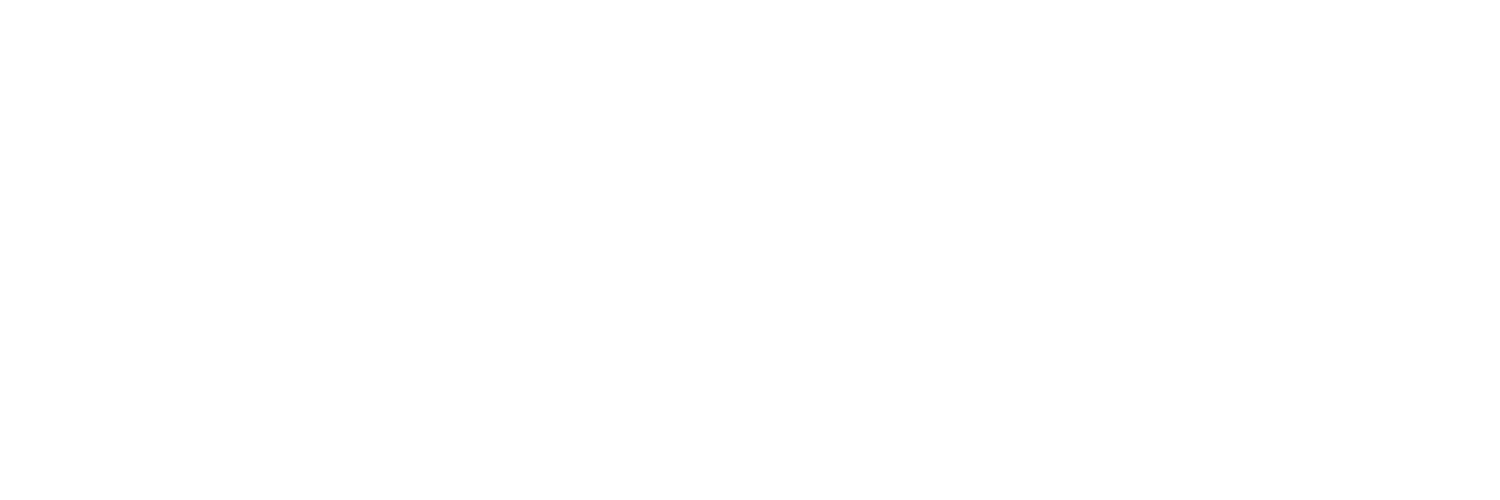

/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:86: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


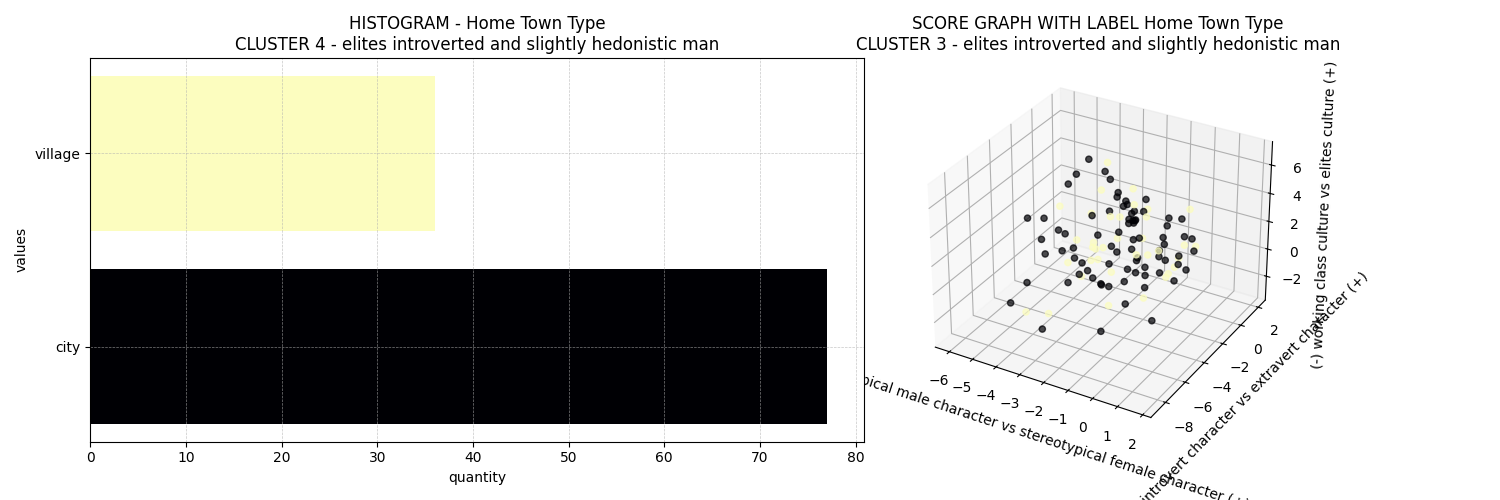

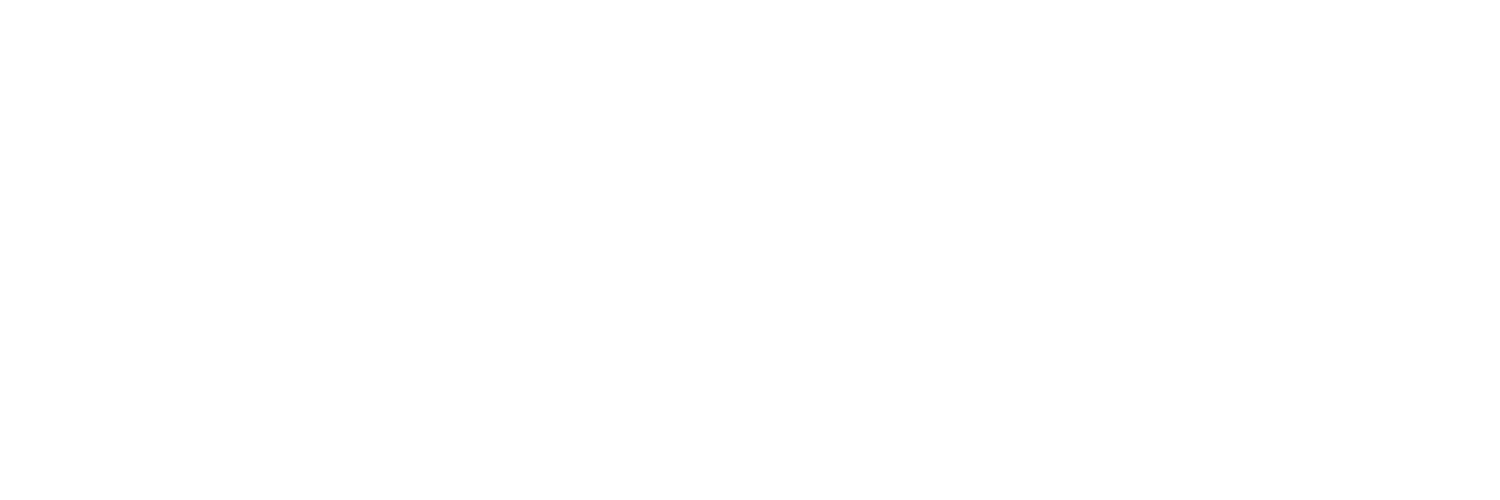

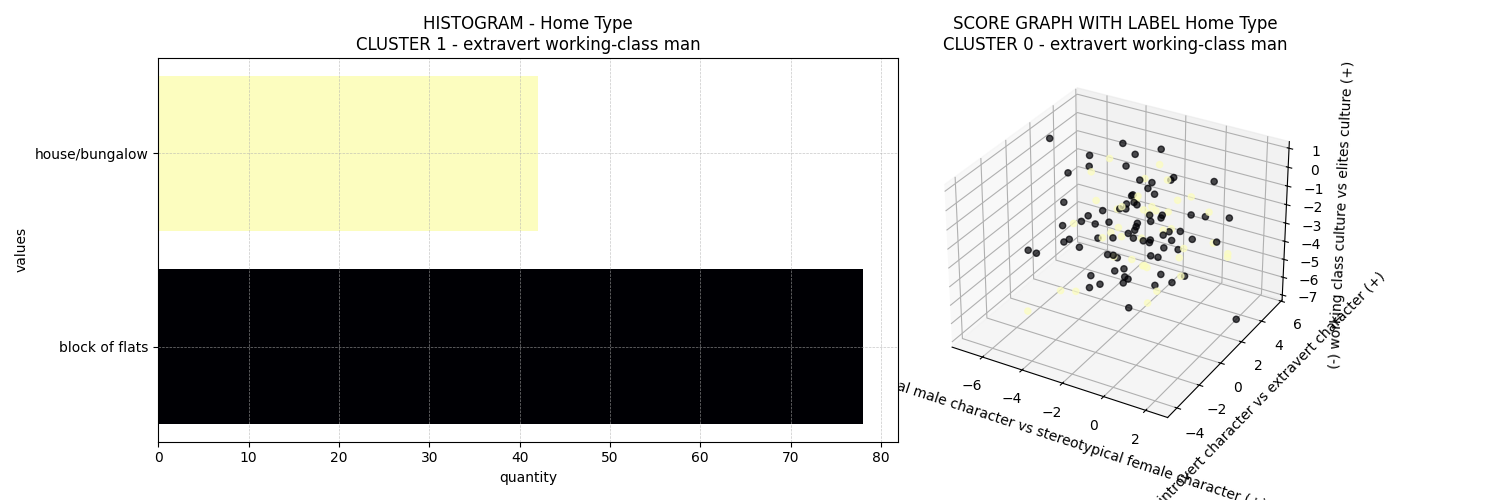

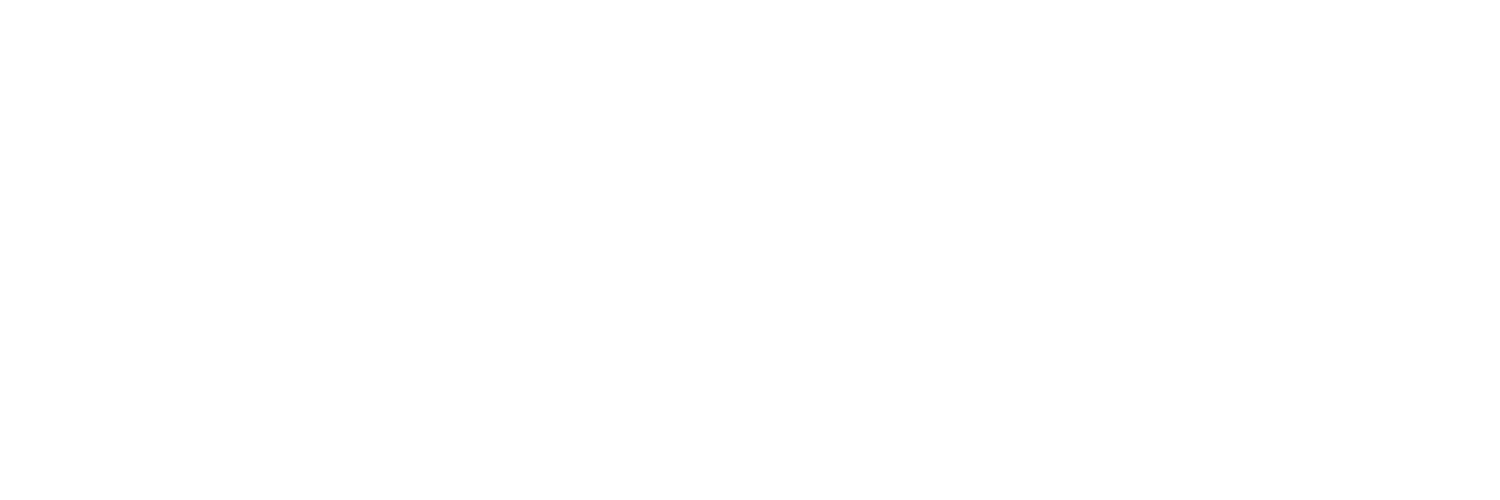

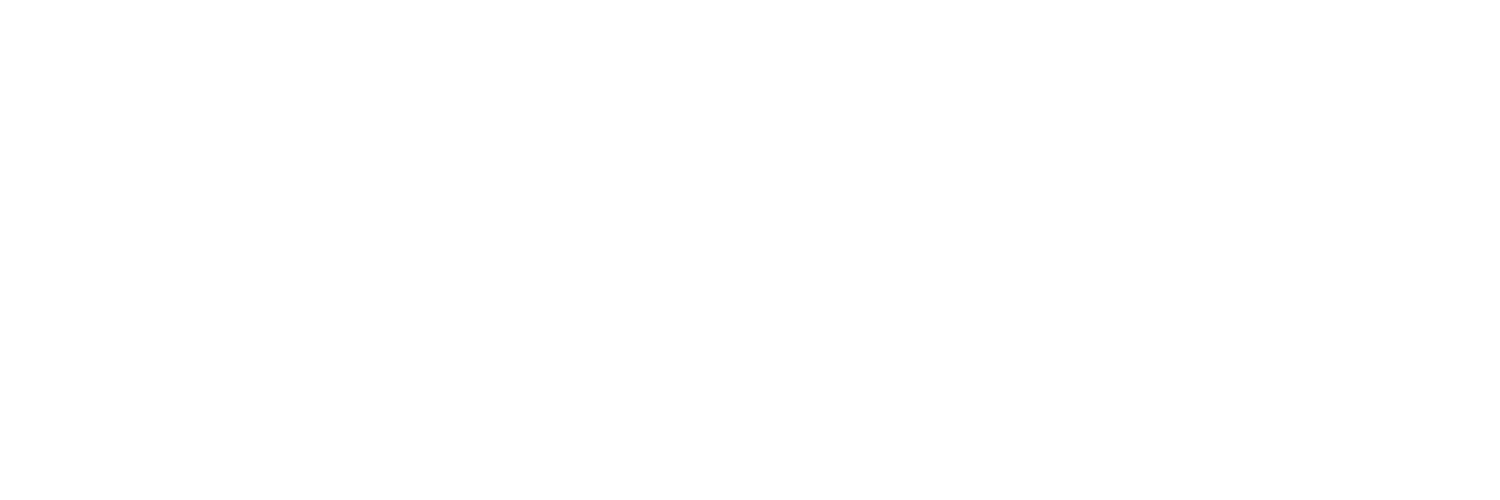

/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:78: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/d6/bp6yc1yj311g8dm36w3xmqs40000gn/T/ipykernel_4463/3113120633.py:86: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


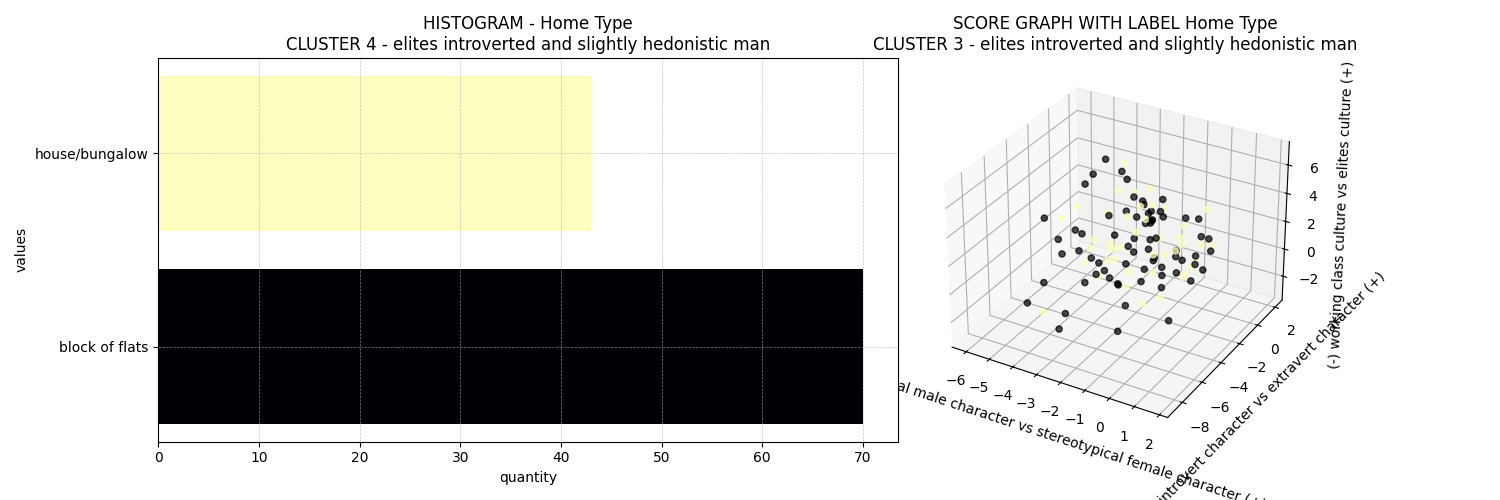

In [11]:
# naming centroids

centroid_names = [
    'extravert working-class man',
    'introvert working-class women',
    'elites extraverts',
    'elites introverted and slightly hedonistic man'
]

# selecting labels

selected_labels = [
    'Gender',
    'Education',
    'Home Town Type',
    'Home Type'
]

# plotting evaluation results

print(f'EXTERNAL EVALUATION ON PLOTS:\n')

for label in selected_labels:
    
    label_values_all = responses_lb[label].values
    label_values, label_counts = np.unique(label_values_all, return_counts=True)
    num_label_values = label_values.shape[0]
    
    num_colors_hist = num_label_values
    cmap_hist = plt.get_cmap('magma')
    color_scat_dict = {label_values[i]: i for i in range(len(label_values))}
    
    color_scat = [cmap_hist(color_scat_dict[i] / (num_label_values - 1)) for i in label_values_all]
    color_hist = cmap_hist(np.linspace(0, 1, num_colors_hist))

    fig_label = plt.figure(figsize=(15, 5))
    
    ax1_label = fig_label.add_subplot(1, 2, 2, projection='3d')
    scat_plot_label = ax1_label.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=20, c=color_scat, alpha=0.7)
    ax1_label.set_title(f'SCORE GRAPH WITH LABEL {label}')
    ax1_label.set_xlabel(pc_names[0])
    ax1_label.set_ylabel(pc_names[1])
    ax1_label.set_zlabel(pc_names[2])
    ax1_label.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()

    ax2_label = fig_label.add_subplot(1, 2, 1)
    ax2_label.barh(label_values, label_counts, color=color_hist)
    ax2_label.set_title(f'HISTOGRAM - {label}')
    ax2_label.set_ylabel('values')
    ax2_label.set_xlabel('quantity')
    ax2_label.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()

    plt.show()

    for cluster in range(k_optimal):
        cluster_positions = np.argwhere(km.labels_ == cluster).flatten()
        cluster_values, cluster_counts = np.unique(label_values_all[cluster_positions], return_counts=True)
        new_counts = np.zeros_like(label_values, dtype=int)

        for val, count in zip(cluster_values, cluster_counts):
            idx = np.where(label_values == val)[0]
            new_counts[idx] = count

        cluster_values, cluster_counts = label_values, new_counts

        fig_clusters = plt.figure(figsize=(15, 5))

        ax1_cluster = fig_clusters.add_subplot(1, 2, 2, projection='3d')
        scat_plot_cluster = ax1_cluster.scatter(Y[cluster_positions, 0], Y[cluster_positions, 1], Y[cluster_positions, 2], 
                                                s=20, c=[color_scat[cp] for cp in cluster_positions], alpha=0.7)
        ax1_cluster.set_title(f'SCORE GRAPH WITH LABEL {label}\nCLUSTER {cluster} - {centroid_names[cluster]}')
        ax1_cluster.set_xlabel(pc_names[0])
        ax1_cluster.set_ylabel(pc_names[1])
        ax1_cluster.set_zlabel(pc_names[2])
        ax1_cluster.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        plt.tight_layout()
    
        ax2_cluster = fig_clusters.add_subplot(1, 2, 1)
        ax2_cluster.barh(label_values, cluster_counts, color=color_hist)
        ax2_cluster.set_title(f'HISTOGRAM - {label}\nCLUSTER {cluster+1} - {centroid_names[cluster]}')
        ax2_cluster.set_ylabel('values')
        ax2_cluster.set_xlabel('quantity')
        ax2_cluster.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        plt.tight_layout()
    
        plt.show()

#### For each selected label, comment the results observed in the visualizations (max 100 words per label):
\
Gender: results proved that PC1: (-) stereotypical man vs stereotypical women (+) was interpreted correctly as points labeled as women are located on the positive side of the axis, while points labeled as man are mostly found on the negative side. Moreover, the cluster analysis confirms this relationship, since clusters named (and described) according to gender show a high level of consistency. The only exception is cluster 4 (“elite, introverted and slightly hedonistic male”), where a small predominance of points labeled as women is observed.

Education: this label was supposed to help with verification of PC3: (-) working class vs elites (+). Although cluster 3 “elites extraverts” contains a significantly higher number of people with higher education compared to other clusters, the overall validation cannot be considered fully successful. The dataset is strongly dominated by people with secondary education, thus every cluster is full of individuals of this education level, limiting the usefulness of this label as an external validation feature.

Home Town Type: this label was intended to support the validation of PC3: (-) working class vs elites (+) and partially PC2: (-) introverts vs extraverts (+). However, the proportions of this label are very similar across all clusters, with a clear dominance of city residents in each group. This means that, one more time, was experienced an imbalanced dataset, where urban respondents significantly outnumbered those from villages, which limits the usefulness of this label as a validation variable.

Home Type: this label was supposed to help with verification of PC3: (-) working class vs elites (+), but even despite cluster 3 “elites extraverts” containing the highest proportion of people living in a house rather than in a block of flats, the validation on other clusters cannot be considered successful. While the general distribution of the values of this label is relatively balanced, “Home Type” alone provides limited information about family status, therefore cannot be considered as a reliable validation of the clusters. 

SHORT SUM UP:
All selected labels, despite "Gender", did not show any pattern in the scatter plots and the points were distributed all over the chart.


## Exercise 6. Cluster Internal Evaluations

In this exercise, you have to do the following operations:
1. For each cluster, measure the corresponding average silhouette score
1. Visualize the silhouette of the clusters and the general one of the clustering and compare them


#### Write the code for computing the silhouette scores and for visualizing them:

SILHOUETTE SCORE PER CLUSTER:



,Silhouette score
extravert working-class man,0.237154
introvert working-class women,0.280632
elites extraverts,0.258893
elites introverted and slightly hedonistic man,0.223320
general,0.166469


INTERNAL EVALUATION ON PLOTS:



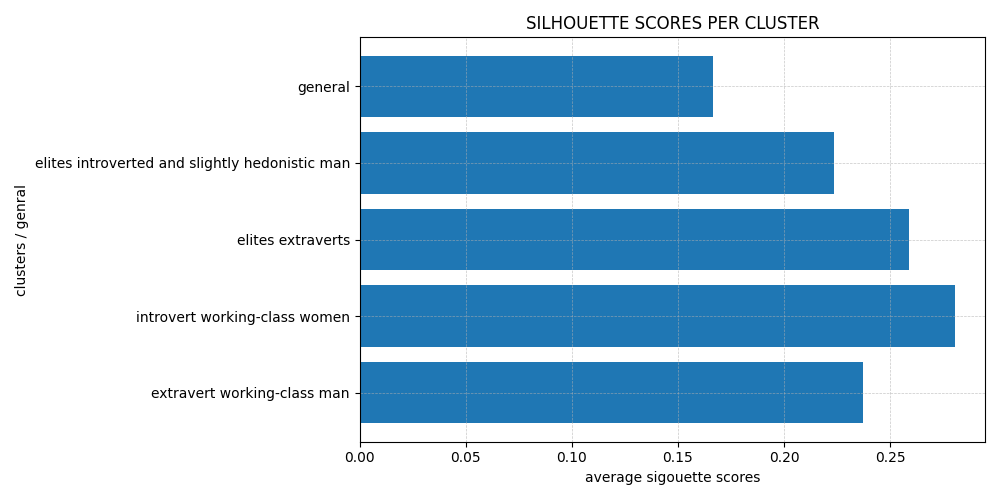

In [12]:
silhouette_scores = silhouette_samples(Y, km.labels_)
cluster_silhouette_scores = [np.mean(km.labels_ == k) for k in range(k_optimal)]

all_silhouette_scores_df = pd.DataFrame(np.array(cluster_silhouette_scores + [silhouette_coef]), 
                                        index=centroid_names + ['general'], columns=['Silhouette score'])

print(f'SILHOUETTE SCORE PER CLUSTER:\n')

display(all_silhouette_scores_df)

print(f'INTERNAL EVALUATION ON PLOTS:\n')

plt.figure(figsize=(10, 5))
plt.barh(all_silhouette_scores_df.index.to_list(), all_silhouette_scores_df['Silhouette score'].values)
plt.ylabel('clusters / genral')
plt.xlabel('average sigouette scores')
plt.title('SILHOUETTE SCORES PER CLUSTER')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

#### Comment the results, also considering the results observed previously (e.g., score graphs, centroids, etc. - max 150 words):
\
The results indicate that the clustering was not very successful. General silhouette score is equal to 0.17 with values ranging from 0.22 to 0.28 for individual clusters, which suggests a low clustering quality and limited separation between groups. Points do not clearly form separate clusters. This outcome was expected, as not many clusters matched their assigned principal component interpretations and usually the labels were spread around clusters without a clear pattern. This may be caused by an imbalanced dataset, as most of the responses came from a similar social group- statistics students and their friends. Moreover the first five principal components explain only about 25% of the total variance. Finally, apart from danger, the available labels were not well suited for validating the clustering results.
